# Detecção e diagnóstico de anomalias em sinais de vibração (CWRU)

**ECM514 Ciência de Dados, Projeto Desafio do 2º semestre. Grupo 4, dataset CWRU.**

O objetivo é responder duas perguntas sobre um rolamento de motor elétrico usando só o sinal de um acelerômetro:
o rolamento mudou de comportamento? (**detecção**) e, se mudou, que tipo de defeito é? (**diagnóstico**).

Trabalhamos com 3 classes: **Normal**, **falha na pista interna (IR)** e **falha na pista externa (OR, posição 6h)**,
sensor do lado do acoplamento (drive end), 48 kHz, quatro cargas do motor (0 a 3 HP) e três tamanhos de defeito (0,007", 0,014" e 0,021").

Esse notebook roda do início ao fim no Colab. Os arquivos `.mat` são baixados na primeira execução (com conferência de SHA-256) se não estiverem em `data/raw/`.

**Três decisões pesam mais nos resultados e são justificadas ao longo do texto.**
Primeiro, usamos 48 kHz nas três classes, porque o baseline Normal só existe a 48 kHz e misturá-lo com falhas a 12 kHz sem reamostrar separaria as classes pela amostragem e não pelo defeito.
Segundo, nenhuma janela de teste compartilha trecho de sinal com janela de treino.
Terceiro, além do split temporal, testamos o modelo em condições que ele nunca viu: uma **carga** inédita (P2) e um **tamanho de defeito** inédito (P3).
Veremos que o cenário padrão do CWRU (P1) é fácil demais para diferenciar métodos, e que a diferença aparece nos protocolos P2 e P3.

In [1]:
import os, sys, time, json, warnings, subprocess, hashlib, urllib.request, urllib.parse
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.io import loadmat
from scipy.signal import butter, sosfiltfilt, hilbert, welch
from scipy.stats import kurtosis, skew
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.svm import OneClassSVM, SVC
from sklearn.covariance import LedoitWolf
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, f1_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})
T0 = time.time()

## 0. Configuração

Todos os parâmetros que alteram resultado ficam aqui. A janela de 0,5 s (24 000 amostras) dá resolução de 2 Hz no espectro do envelope,
suficiente para separar a frequência de falha da pista externa (cerca de 107 Hz) da pista interna (cerca de 162 Hz).
As frequências características do rolamento SKF 6205-2RS (lado do acoplamento) são múltiplos da rotação do eixo, BPFO = 3,5848 x fr e BPFI = 5,4152 x fr
(valores da página do CWRU, conferidos pela geometria logo abaixo).

Se quiser uma execução mais rápida, `USE_EXTRA_SEVERITIES = False` roda só com defeito de 0,007" (12 arquivos, sem o protocolo P3).

In [2]:
USE_EXTRA_SEVERITIES = True    # False: só 0,007" (sem P3)
FS = 48_000                    # taxa de amostragem (Hz), igual para as 3 classes
WIN = 24_000                   # janela de 0,5 s
HOP_FIT = 12_000               # passo (50% de sobreposição) nas janelas de treino
HOP_EVAL = 24_000              # passo (sem sobreposição) nas janelas de teste
GUARD = 12_000                 # folga entre trecho de treino e trecho de teste (0,25 s)
TRAIN_FRAC = 0.70              # primeiros 70% de cada sinal Normal (e de cada sinal no P1) para treino
K_FOLDS_THR = 5                # blocos temporais para calibrar o limiar do detector
THR_QUANTILE = 0.95            # limiar = percentil 95 dos escores de janelas normais fora da amostra
K_BPFO, K_BPFI = 3.5848, 5.4152
NOMINAL_RPM = {0: 1797, 1: 1772, 2: 1750, 3: 1730}   # só usado quando o .mat não traz a variável de RPM
CLASSES = ['Normal', 'IR', 'OR']
LOADS = [0, 1, 2, 3]
SEVS = ['007', '014', '021']   # tamanho do defeito em milésimos de polegada
SEV_LABEL = {'007': '0,007"', '014': '0,014"', '021': '0,021"'}

# conferência da geometria do rolamento 6205-2RS (polegadas): 9 esferas, esfera 0,3126, diâmetro primitivo 1,537
n_b, d_b, D_p = 9, 0.3126, 1.537
print('BPFO/fr pela geometria: %.4f | BPFI/fr pela geometria: %.4f' % (n_b / 2 * (1 - d_b / D_p), n_b / 2 * (1 + d_b / D_p)))

BPFO/fr pela geometria: 3.5848 | BPFI/fr pela geometria: 5.4152


## 1. Dados

**Fonte:** Case Western Reserve University Bearing Data Center (Loparo, K. A.). Bancada com motor de 2 HP, acelerômetro no mancal do lado do acoplamento,
defeitos introduzidos por eletroerosão (EDM) em rolamentos SKF 6205-2RS. Usamos o sinal `DE_time` (aceleração, em g).

**Arquivos:** Normal 97 a 100 (cargas 0 a 3 HP), pista interna (IR) 0,007" 109 a 112, 0,014" 174 a 177, 0,021" 213 a 215 e 217, e pista externa (OR, posição 6h) 0,007" 135 a 138, 0,014" 201 a 204, 0,021" 238 a 241.
Todos os arquivos de defeito são a 48 kHz, taxa em que o baseline Normal foi gravado.

Os arquivos vêm de um espelho público no GitHub (o site original exige cliques manuais). Cada arquivo é conferido por tamanho e SHA-256.
Os arquivos de 12 kHz distribuídos no pacote do Kaggle indicado no enunciado são idênticos byte a byte aos originais do CWRU, mas esse pacote tem duas armadilhas
(um Normal duplicado e Normal a 48 kHz junto de falhas a 12 kHz), detalhadas no relatório e em `scripts/auditoria_kaggle.py`. Por isso usamos os arquivos originais a 48 kHz.

In [3]:
IN_COLAB = 'google.colab' in sys.modules
REPO_URL = 'https://github.com/IMT-CD-PAPA/IMT_CD_PROJETO_2.git'
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if IN_COLAB and not (ROOT / 'data').exists():
    try:
        subprocess.run(['git', 'clone', '--depth', '1', REPO_URL], check=True)
        ROOT = ROOT / 'IMT_CD_PROJETO_2'
    except Exception as e:
        print('Não foi possível clonar o repositório (', e, '). Seguindo só com download dos dados.')
os.chdir(ROOT)
RAW, RES = ROOT / 'data' / 'raw', ROOT / 'results'
FIG = RES / 'figures'
FIG.mkdir(parents=True, exist_ok=True)
RAW.mkdir(parents=True, exist_ok=True)
MIRROR = 'https://raw.githubusercontent.com/s-whynot/CWRU-dataset/main/'

# (classe, severidade, carga): (arquivo local, caminho no espelho, bytes, SHA-256, prefixo da variável dentro do .mat)
# Normal não tem severidade, por isso usa '-'. O prefixo da variável nem sempre é o número do arquivo (ver 1.1).
REC_FILES = {
    ('Normal', '-', 0): ('97_Normal_0.mat', 'Normal/97_Normal_0.mat', 3903344, '16bf48babcf1c7ac224bc1a81cd9eafdb27e42d5cf559761907e067e8eeadf3c', 'X097'),
    ('Normal', '-', 1): ('98_Normal_1.mat', 'Normal/98_Normal_1.mat', 7742720, '37e6612c05e65c415dcfa2ab27a3fda648a5863160fa898b884a14743044e045', 'X098'),
    ('Normal', '-', 2): ('99_Normal_2.mat', 'Normal/99_Normal_2.mat', 15503928, '4b97e6b5361f45efb6951dc3b1aebcdb3b89cb69d0f96d6f5c297dd9f45eee75', 'X099'),
    ('Normal', '-', 3): ('100_Normal_3.mat', 'Normal/100_Normal_3.mat', 7770624, '88a5990cb541320e91505a1d72139e1993500ffe6e292a451011667f4138ca78', 'X100'),
    ('IR', '007', 0): ('109_0.mat', '48k_Drive_End_Bearing_Fault_Data/IR/007/109_0.mat', 3903344, 'daddef5f784879becdf8fefbe2453f11c3cfc8d061a2a671da2f546d1bb48460', 'X109'),
    ('IR', '007', 1): ('110_1.mat', '48k_Drive_End_Bearing_Fault_Data/IR/007/110_1.mat', 7779920, '9e2bc579af6f4e6d9d26bf63b7ed84ecba7775740d56a3737cc8f04f73c22d1a', 'X110'),
    ('IR', '007', 2): ('111_2.mat', '48k_Drive_End_Bearing_Fault_Data/IR/007/111_2.mat', 7770624, 'a2e64a397a990efb91ba55252a84796f755bda3eb097c4b47cc0730a08dab309', 'X111'),
    ('IR', '007', 3): ('112_3.mat', '48k_Drive_End_Bearing_Fault_Data/IR/007/112_3.mat', 7770624, '1775db11999f268c6ccf04b3ee19857f90a3636f4a582f1abd9a627f991e72d4', 'X112'),
    ('OR', '007', 0): ('135_0.mat', '48k_Drive_End_Bearing_Fault_Data/OR/007/@6/135_0.mat', 3896944, '5a1c3ceec1f2b58af9e01051e425aa9d31dd018f58a8d31cda25bbdb1ac6dca9', 'X135'),
    ('OR', '007', 1): ('136_1.mat', '48k_Drive_End_Bearing_Fault_Data/OR/007/@6/136_1.mat', 7789200, '37f259eebbc92afa8bd1b445d02af14e83608a48cd7a3cf5c323515ddc2d0f24', 'X136'),
    ('OR', '007', 2): ('137_2.mat', '48k_Drive_End_Bearing_Fault_Data/OR/007/@6/137_2.mat', 7789200, 'a81b621153e426aa32848be8157c42bcd81065a28ac7655a9a6597f3889fa3ef', 'X137'),
    ('OR', '007', 3): ('138_3.mat', '48k_Drive_End_Bearing_Fault_Data/OR/007/@6/138_3.mat', 7807760, 'b43eeb67badeb129047ddd3658bf673815dc4bd445facb4217eb04653bb2e11d', 'X138'),
    ('IR', '014', 0): ('174_0.mat', '48k_Drive_End_Bearing_Fault_Data/IR/014/174_0.mat', 1020944, 'ca7113a900d9217aa5632e0dad4f8791caed4d314321daa011719e1bc99f3026', 'X173'),
    ('IR', '014', 1): ('175_1.mat', '48k_Drive_End_Bearing_Fault_Data/IR/014/175_1.mat', 17849704, '18302e96425ad163db699da3a2ca63d8f6ef4dfc99172e97ab21a8a77a83ac17', 'X175'),
    ('IR', '014', 2): ('176_2.mat', '48k_Drive_End_Bearing_Fault_Data/IR/014/176_2.mat', 7807760, '569c7b292018e7e88cf4b375b091433c7566b9503545188979e93f6428427247', 'X176'),
    ('IR', '014', 3): ('177_3.mat', '48k_Drive_End_Bearing_Fault_Data/IR/014/177_3.mat', 7761344, '5cffc5aa2b1e5cc65a97ebcfaa369b886ad8db8b8840e0e0095e97b8b9be4c16', 'X177'),
    ('IR', '021', 0): ('213_0.mat', '48k_Drive_End_Bearing_Fault_Data/IR/021/213_0.mat', 3909760, '6afb81f36a9efcdd370a52166d71c13cb42278c7de22752c81d4b2a22fa133f0', 'X213'),
    ('IR', '021', 1): ('214_1.mat', '48k_Drive_End_Bearing_Fault_Data/IR/021/214_1.mat', 7761344, 'a8fe29f358b7f9c140f38e0cd7fbafdd7441c44e30a5b704ecb9be64cbb841ed', 'X214'),
    ('IR', '021', 2): ('215_2.mat', '48k_Drive_End_Bearing_Fault_Data/IR/021/215_2.mat', 7863472, '1e3d65088782a29aa70004896db4b9836499dd12edd3c58fb496f4befca6f746', 'X215'),
    ('IR', '021', 3): ('217_3.mat', '48k_Drive_End_Bearing_Fault_Data/IR/021/217_3.mat', 15689680, 'fb5b067c04b4c8449cbdd4ac4e376d7eb0804b9203efcab513e42aaf2f6a2cf7', 'X217'),
    ('OR', '014', 0): ('201@6_0.mat', '48k_Drive_End_Bearing_Fault_Data/OR/014/201@6_0.mat', 3922576, '6c27615a61f19f05f65cf2cc2aa4bca5bda051c9d93a708d0ee8baf5138834fa', 'X201'),
    ('OR', '014', 1): ('202@6_1.mat', '48k_Drive_End_Bearing_Fault_Data/OR/014/202@6_1.mat', 7752064, '16f1a7eadbd6703a7a1ab1a32f8d7b97b6b85c1b31b1e760c123a9e175d8ae63', 'X202'),
    ('OR', '014', 2): ('203@6_2.mat', '48k_Drive_End_Bearing_Fault_Data/OR/014/203@6_2.mat', 7789200, '3cad2848f4c96cde04fc06ca0f541ad663298ecb50eb7fc74e25b72ab29e1c5a', 'X203'),
    ('OR', '014', 3): ('204@6_3.mat', '48k_Drive_End_Bearing_Fault_Data/OR/014/204@6_3.mat', 7817056, 'f3b1736698a580c2ea44cce78045833a9e76476d9153da8af5275c2e30e38a10', 'X204'),
    ('OR', '021', 0): ('238_0.mat', '48k_Drive_End_Bearing_Fault_Data/OR/021/@6/238_0.mat', 3941808, '63209a4057f199beb42beedf5b4481987fdb3ac746c46777dd385d689bc481df', 'X238'),
    ('OR', '021', 1): ('239_1.mat', '48k_Drive_End_Bearing_Fault_Data/OR/021/@6/239_1.mat', 7826336, '4ba7dc55258359577a68f6de5c0ff6675776d2b2c30d691dd4d71640e34834af', 'X239'),
    ('OR', '021', 2): ('240_2.mat', '48k_Drive_End_Bearing_Fault_Data/OR/021/@6/240_2.mat', 7807760, 'c5d8b4db09880b660da88865fff0e81afef0f5ad68bdf0ad7b75c722ae3e7e1c', 'X240'),
    ('OR', '021', 3): ('241_3.mat', '48k_Drive_End_Bearing_Fault_Data/OR/021/@6/241_3.mat', 7826336, 'cb64eed96d401837c25df63598b7d1a00868368e1ed503a8dcef1e5226ec9caa', 'X241'),
}
REC_ALL = REC_FILES
REC_FILES = {k: v for k, v in REC_ALL.items() if USE_EXTRA_SEVERITIES or k[1] in ('-', '007')}
BASE_KEYS = [k for k in REC_FILES if k[1] in ('-', '007')]   # Normal e defeito de 0,007": usados em P1 e P2

def sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b''):
            h.update(chunk)
    return h.hexdigest()

def ensure_data():
    for key, (name, rel, size, digest, var) in REC_FILES.items():
        p = RAW / name
        if not (p.exists() and p.stat().st_size == size):
            print('baixando', name)
            urllib.request.urlretrieve(MIRROR + urllib.parse.quote(rel), p)
        assert p.stat().st_size == size, f'{name}: tamanho inesperado'
        assert sha256(p) == digest, f'{name}: SHA-256 diferente do esperado'
    print('dados ok:', len(REC_FILES), 'arquivos verificados (tamanho e SHA-256)')

ensure_data()

dados ok: 28 arquivos verificados (tamanho e SHA-256)


### 1.1 Inventário e conferências de sanidade

O CWRU tem armadilhas de organização que passam despercebidas se o código só "pega a primeira variável". Elas são checadas de forma explícita:

**(a) Variável certa dentro do `.mat`.** O `99.mat` (Normal, 2 HP) traz `X098_DE_time` (cópia do arquivo 98) e `X099_DE_time`.
O `174_0.mat` guarda a variável `X173` e só tem 1,3 s de sinal. O `175_1.mat` traz, além da `X175`, uma variável `X217` sem RPM associado e diferente da `X217` do `217_3.mat`,
e o `217_3.mat` repete o `X215` do arquivo 215. Aqui cada arquivo tem a variável escolhida de forma explícita, e conferimos as duplicatas.

**(b) Taxa de amostragem.** Se a taxa assumida estiver certa, o pico do espectro perto da rotação do eixo cai em `RPM/60`. Testamos 48 kHz e 12 kHz e usamos a mediana entre os arquivos,
porque em alguns arquivos de defeito o pico dominante perto de 1x pode ser outro componente (os casos fora do padrão são listados).

**(c) Rotação.** Alguns arquivos não trazem a variável de RPM (98 e 99). Nesses usamos a rotação nominal da carga e confirmamos pelo pico de 1x no espectro.

In [4]:
def shaft_peak(x, fs, fr):
    f, p = welch(x - x.mean(), fs=fs, nperseg=min(len(x), fs * 4))
    m = (f > fr - 8) & (f < fr + 8)
    return f[m][np.argmax(p[m])]

REC, SIG, RPM, rows = {}, {}, {}, []
for key, (name, rel, size, digest, var) in REC_FILES.items():
    d = loadmat(RAW / name)
    k = f'{var}_DE_time'
    assert k in d, f'{k} não encontrado em {name}'
    x = d[k].ravel().astype(np.float64)
    rk = f'{var}RPM'
    rpm = float(d[rk].ravel()[0]) if rk in d else float(NOMINAL_RPM[key[2]])
    SIG[key], RPM[key] = x, rpm
    fr = rpm / 60
    rows.append({'classe': key[0], 'sev': key[1], 'carga_HP': key[2], 'arquivo': name, 'variavel': k, 'amostras': len(x),
                 'dur_s@48k': round(len(x) / FS, 2), 'rpm': rpm, 'rpm_fonte': 'arquivo' if rk in d else 'nominal', 'fr_Hz': round(fr, 2),
                 'pico_1x@48k': shaft_peak(x, 48_000, fr), 'pico_1x@12k': shaft_peak(x, 12_000, fr),
                 'outras_DE': [q for q in d if q.endswith('DE_time') and q != k]})
inventario = pd.DataFrame(rows)
REC = list(SIG.keys())
display(inventario.drop(columns=['pico_1x@12k']))
inventario.to_csv(RES / 'inventario_arquivos.csv', index=False, encoding='utf-8')

d99 = loadmat(RAW / REC_FILES[('Normal', '-', 2)][0])
print('X098 dentro do 99.mat é idêntico ao sinal do arquivo 98:', np.array_equal(d99['X098_DE_time'].ravel(), SIG[('Normal', '-', 1)]))
print('X099 é diferente de X098 dentro do 99.mat:', not np.array_equal(d99['X099_DE_time'].ravel(), d99['X098_DE_time'].ravel()))
if USE_EXTRA_SEVERITIES:
    d175, d217, d215 = (loadmat(RAW / n) for n in ('175_1.mat', '217_3.mat', '215_2.mat'))
    print('X217 extra dentro do 175_1.mat é diferente do X217 do 217_3.mat:', not np.array_equal(d175['X217_DE_time'].ravel(), d217['X217_DE_time'].ravel()))
    print('variáveis do 174_0.mat:', [k for k in loadmat(RAW / '174_0.mat') if not k.startswith('__')])
    print('X215 dentro do 217_3.mat é igual ao X215 do 215_2.mat:', np.array_equal(d217['X215_DE_time'].ravel(), d215['X215_DE_time'].ravel()))
dup = [(a, b) for i, a in enumerate(REC) for b in REC[i + 1:] if len(SIG[a]) == len(SIG[b]) and np.array_equal(SIG[a][:5000], SIG[b][:5000])]
print('pares de sinais duplicados entre os escolhidos:', dup)
e48 = (inventario['pico_1x@48k'] - inventario['fr_Hz']).abs(); e12 = (inventario['pico_1x@12k'] - inventario['fr_Hz']).abs()
print(f'desvio mediano do pico de 1x assumindo 48 kHz: {e48.median():.2f} Hz (máx {e48.max():.2f}) | assumindo 12 kHz: {e12.median():.2f} Hz (mín {e12.min():.2f})')
print('arquivos em que o pico dominante perto de 1x ficou a mais de 1 Hz de RPM/60 (assumindo 48 kHz):')
display(inventario.loc[e48 > 1, ['classe', 'sev', 'carga_HP', 'arquivo', 'amostras', 'fr_Hz', 'pico_1x@48k']])
assert e48.median() < 0.75 and e12.median() > 3.0, 'a taxa de amostragem não é 48 kHz'

,classe,sev,carga_HP,arquivo,variavel,amostras,dur_s@48k,rpm,rpm_fonte,fr_Hz,pico_1x@48k,outras_DE
0,Normal,-,0,97_Normal_0.mat,X097_DE_time,243938,5.08,1796.0,arquivo,29.93,30.000000,[]
1,Normal,-,1,98_Normal_1.mat,X098_DE_time,483903,10.08,1772.0,nominal,29.53,29.500000,[]
2,Normal,-,2,99_Normal_2.mat,X099_DE_time,485063,10.11,1750.0,nominal,29.17,29.250000,[X098_DE_time]
3,Normal,-,3,100_Normal_3.mat,X100_DE_time,485643,10.12,1725.0,arquivo,28.75,28.750000,[]
4,IR,007,0,109_0.mat,X109_DE_time,243938,5.08,1796.0,arquivo,29.93,30.000000,[]
5,IR,007,1,110_1.mat,X110_DE_time,486224,10.13,1772.0,arquivo,29.53,29.500000,[]
6,IR,007,2,111_2.mat,X111_DE_time,485643,10.12,1748.0,arquivo,29.13,29.000000,[]
7,IR,007,3,112_3.mat,X112_DE_time,485643,10.12,1721.0,arquivo,28.68,28.750000,[]
8,OR,007,0,135_0.mat,X135_DE_time,243538,5.07,1796.0,arquivo,29.93,30.000000,[]
9,OR,007,1,136_1.mat,X136_DE_time,486804,10.14,1774.0,arquivo,29.57,29.500000,[]


X098 dentro do 99.mat é idêntico ao sinal do arquivo 98: True
X099 é diferente de X098 dentro do 99.mat: True
X217 extra dentro do 175_1.mat é diferente do X217 do 217_3.mat: True
variáveis do 174_0.mat: ['X173_DE_time', 'X173_FE_time', 'X173RPM']
X215 dentro do 217_3.mat é igual ao X215 do 215_2.mat: True
pares de sinais duplicados entre os escolhidos: []
desvio mediano do pico de 1x assumindo 48 kHz: 0.07 Hz (máx 7.02) | assumindo 12 kHz: 6.86 Hz (mín 0.07)
arquivos em que o pico dominante perto de 1x ficou a mais de 1 Hz de RPM/60 (assumindo 48 kHz):


,classe,sev,carga_HP,arquivo,amostras,fr_Hz,pico_1x@48k
12,IR,014,0,174_0.mat,63788,29.93,26.337242
15,IR,014,3,177_3.mat,485063,28.77,21.750000


### 1.2 Olhando os sinais

No tempo, o defeito aparece como impactos periódicos. No espectro, o defeito injeta energia em altas frequências (ressonâncias excitadas pelos impactos),
região que o espectro de envelope (seção 3) explora.

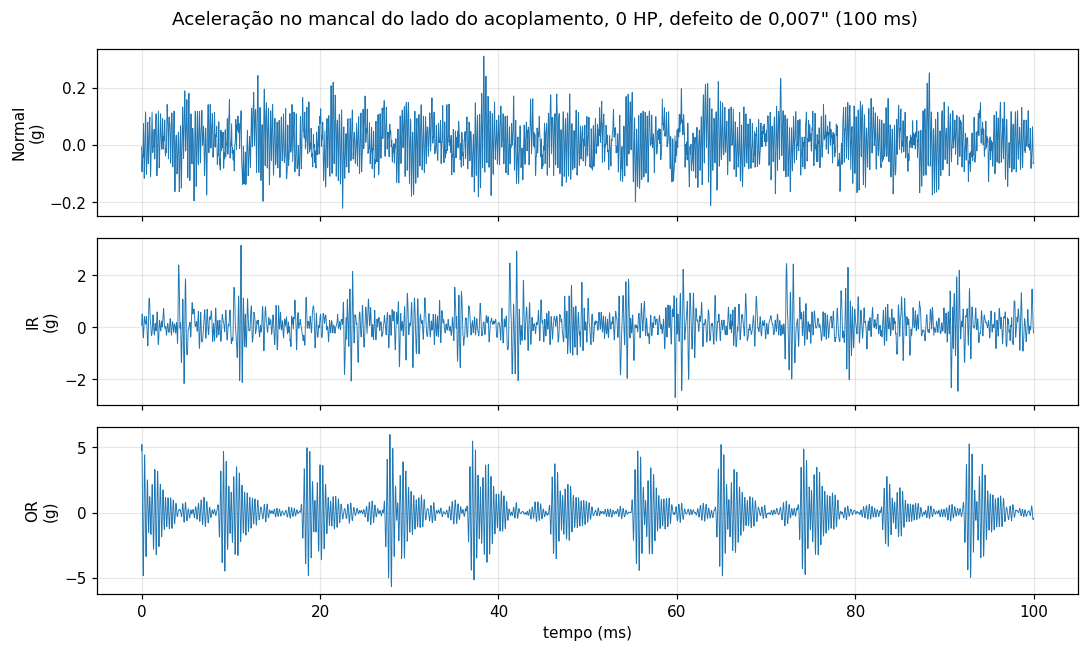

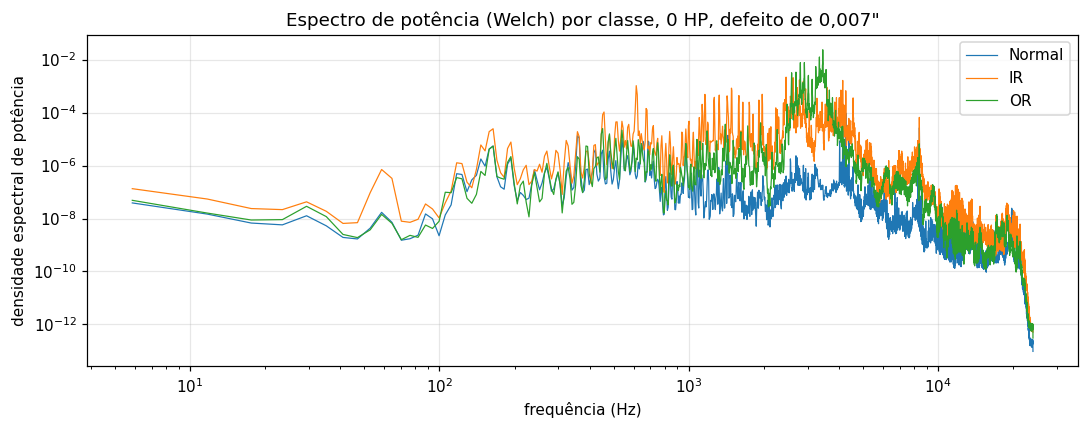

In [5]:
BASE_SEV = {'Normal': '-', 'IR': '007', 'OR': '007'}
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
t = np.arange(int(0.1 * FS)) / FS
for ax, cls in zip(axes, CLASSES):
    ax.plot(t * 1000, SIG[(cls, BASE_SEV[cls], 0)][FS:FS + len(t)], lw=0.6)
    ax.set_ylabel(f'{cls}\n(g)')
axes[-1].set_xlabel('tempo (ms)')
fig.suptitle('Aceleração no mancal do lado do acoplamento, 0 HP, defeito de 0,007" (100 ms)')
fig.tight_layout(); fig.savefig(FIG / '01_sinais_tempo.png', bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
for cls in CLASSES:
    x = SIG[(cls, BASE_SEV[cls], 0)]
    f, p = welch(x - x.mean(), fs=FS, nperseg=8192)
    ax.loglog(f[1:], p[1:], lw=0.8, label=cls)
ax.set_xlabel('frequência (Hz)'); ax.set_ylabel('densidade espectral de potência'); ax.legend()
ax.set_title('Espectro de potência (Welch) por classe, 0 HP, defeito de 0,007"')
fig.tight_layout(); fig.savefig(FIG / '02_psd_classes.png', bbox_inches='tight'); plt.show()

## 2. Metodologia de divisão dos dados

Cada sinal é cortado em janelas de 0,5 s. O cuidado central: **janelas vizinhas do mesmo sinal são quase a mesma amostra**.
Se uma entra no treino e a vizinha entra no teste, o modelo "reconhece" o trecho e a métrica não diz nada sobre diagnóstico de verdade.
Por isso nenhum protocolo abaixo deixa janelas de treino e teste se tocarem no tempo. Em todo treino de detecção, **só janelas Normal** entram no ajuste do modelo.

**P1, split temporal (mesma máquina, condições já vistas).** Os primeiros 70% de cada sinal viram treino e os últimos 30% viram teste, com folga de 0,25 s entre eles. Usa Normal e defeito de 0,007".

**P2, leave-one-load-out (carga nunca vista).** Treina com 3 das 4 cargas e testa na carga restante, nos 4 arranjos possíveis. Usa Normal e defeito de 0,007".

**P3, leave-one-severity-out (tamanho de defeito nunca visto).** Treina com defeitos de dois tamanhos (todas as cargas) e testa no tamanho restante, nos 3 arranjos possíveis.
O Normal não tem tamanho de defeito, então segue o mesmo corte temporal do P1 (70% treino, 30% teste). É o teste mais exigente, pois mede se o modelo aprendeu a *assinatura física* do defeito ou só a amplitude do tamanho que viu.

In [6]:
def build_table(files, a_frac, b_frac, hop, guard=0):
    rows = []
    for key in files:
        N = len(SIG[key])
        a, b = int(a_frac * N) + guard, int(b_frac * N)
        rows += [(key[0], key[1], key[2], s) for s in range(a, b - WIN + 1, hop)]
    return pd.DataFrame(rows, columns=['cls', 'sev', 'load', 'start'])

def lolo_tables(L):
    tr = build_table([k for k in BASE_KEYS if k[2] != L], 0.0, 1.0, HOP_FIT)
    te = build_table([k for k in BASE_KEYS if k[2] == L], 0.0, 1.0, HOP_EVAL)
    return tr, te

NORMAL_KEYS = [k for k in REC if k[0] == 'Normal']
def fault_keys(sevs):
    return [k for k in REC if k[0] != 'Normal' and k[1] in sevs]

def sev_tables(held):
    trs = [s for s in SEVS if s != held]
    tr = pd.concat([build_table(fault_keys(trs), 0.0, 1.0, HOP_FIT), build_table(NORMAL_KEYS, 0.0, TRAIN_FRAC, HOP_FIT)], ignore_index=True)
    te = pd.concat([build_table(fault_keys([held]), 0.0, 1.0, HOP_EVAL), build_table(NORMAL_KEYS, TRAIN_FRAC, 1.0, HOP_EVAL, guard=GUARD)], ignore_index=True)
    return tr, te

P1_train = build_table(BASE_KEYS, 0.0, TRAIN_FRAC, HOP_FIT)
P1_test = build_table(BASE_KEYS, TRAIN_FRAC, 1.0, HOP_EVAL, guard=GUARD)
contagem = pd.DataFrame({'P1 treino': P1_train.cls.value_counts(), 'P1 teste': P1_test.cls.value_counts()})
for L in LOADS:
    tr, te = lolo_tables(L)
    contagem[f'P2 treino (sem {L} HP)'] = tr.cls.value_counts(); contagem[f'P2 teste ({L} HP)'] = te.cls.value_counts()
if USE_EXTRA_SEVERITIES:
    for s in SEVS:
        tr, te = sev_tables(s)
        contagem[f'P3 treino (sem {s})'] = tr.cls.value_counts(); contagem[f'P3 teste ({s})'] = te.cls.value_counts()
print('janelas de 0,5 s por classe e protocolo')
display(contagem.reindex(CLASSES))
contagem.reindex(CLASSES).to_csv(RES / 'contagem_janelas.csv', encoding='utf-8')

janelas de 0,5 s por classe e protocolo


,P1 treino,P1 teste,P2 treino (sem 0 HP),P2 teste (0 HP),P2 treino (sem 1 HP),P2 teste (1 HP),P2 treino (sem 2 HP),P2 teste (2 HP),P2 treino (sem 3 HP),P2 teste (3 HP),P3 treino (sem 007),P3 teste (007),P3 treino (sem 014),P3 teste (014),P3 treino (sem 021),P3 teste (021)
cls,,,,,,,,,,,,,,,,
Normal,94,17,117,10,97,20,97,20,97,20,94,17,94,17,94,17
IR,94,17,117,10,97,20,97,20,97,20,248,70,272,57,248,70
OR,94,17,117,10,97,20,97,20,97,20,272,70,272,70,272,70


## 3. Extração de atributos

Dois conjuntos, com papéis diferentes.

**Atributos para detecção (não supervisionados):** 7 estatísticas no tempo (RMS, pico, fator de crista, curtose, assimetria, fator de forma, fator de impulso)
e 10 energias logarítmicas em faixas de frequência. Nada disso usa rótulo de falha.

**Atributos para diagnóstico:** as 7 estatísticas no tempo mais 10 atributos do **espectro de envelope**, que seguem Randall e Antoni (2011).
O sinal passa por um passa-faixa em volta de uma ressonância estrutural, extrai-se o envelope por Hilbert e analisa-se o espectro desse envelope.
Defeito na pista externa gera picos em BPFO e harmônicas, na pista interna em BPFI (com bandas laterais em BPFI ± 1x, por causa da modulação pela rotação).
Cada atributo é a razão sinal-ruído do pico (em log10) contra a mediana local do espectro, o que o torna pouco sensível à amplitude absoluta, que muda com a carga e com o tamanho do defeito.

A **faixa de demodulação** é escolhida por varredura usando só janelas de falha do conjunto de treino (nunca do teste): vence a faixa que maximiza a razão sinal-ruído em BPFI para a classe IR e em BPFO para a classe OR.

faixa de demodulação escolhida no treino do P1: 1000 a 5000 Hz (10.0 s)


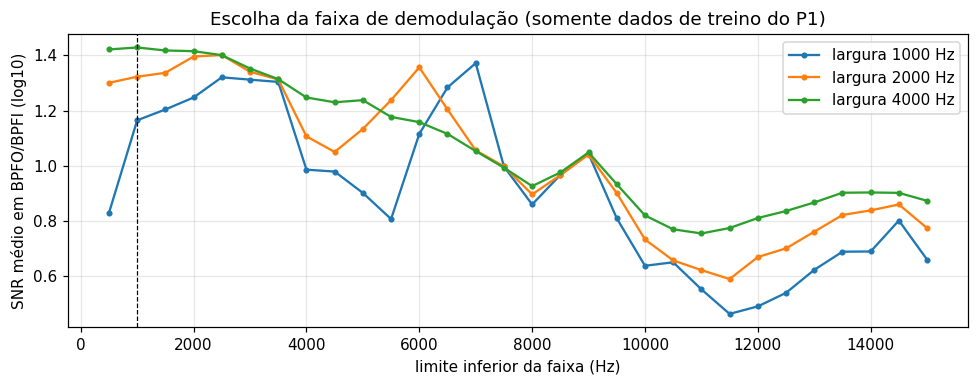

In [7]:
WINDOW = np.hanning(WIN)
DF = FS / WIN
TOL_BINS = 2
REF_BINS = int(40 / DF)
FREQS = np.fft.rfftfreq(WIN, 1 / FS)
BAND_EDGES = [50, 500, 1000, 2000, 3000, 4000, 6000, 8000, 12000, 16000, 24000]
BAND_IDX = [(FREQS >= lo) & (FREQS < hi) for lo, hi in zip(BAND_EDGES[:-1], BAND_EDGES[1:])]
TIME_NAMES = ['rms', 'pico', 'crista', 'curtose', 'assimetria', 'fator_forma', 'fator_impulso']
BAND_NAMES = [f'banda_{lo / 1000:g}-{hi / 1000:g}kHz' for lo, hi in zip(BAND_EDGES[:-1], BAND_EDGES[1:])]

def env_freqs(fr):
    return {'env_bpfo1': K_BPFO * fr, 'env_bpfo2': 2 * K_BPFO * fr, 'env_bpfo3': 3 * K_BPFO * fr,
            'env_bpfi1': K_BPFI * fr, 'env_bpfi2': 2 * K_BPFI * fr, 'env_bpfi3': 3 * K_BPFI * fr,
            'env_1x': fr, 'env_2x': 2 * fr, 'env_bpfi_lsb': K_BPFI * fr - fr, 'env_bpfi_usb': K_BPFI * fr + fr}

ENV_NAMES = list(env_freqs(30.0))
DET_COLS = TIME_NAMES + BAND_NAMES
FEATURE_SETS = {'tempo': TIME_NAMES, 'espectro (faixas)': BAND_NAMES, 'envelope': ENV_NAMES, 'tempo + envelope': TIME_NAMES + ENV_NAMES}
MAIN_SET = 'tempo + envelope'
MAIN_COLS = FEATURE_SETS[MAIN_SET]

def time_feats(W):
    a = np.abs(W); rms = np.sqrt((W ** 2).mean(1)); pk = a.max(1); ma = a.mean(1)
    return np.column_stack([rms, pk, pk / rms, kurtosis(W, axis=1, fisher=False), skew(W, axis=1), rms / ma, pk / ma])

def band_energy_feats(W):
    P = np.abs(np.fft.rfft(W * WINDOW, axis=1)) ** 2
    return np.column_stack([np.log10(P[:, m].sum(axis=1) + 1e-12) for m in BAND_IDX])

def env_spectrum(W, band):
    sos = butter(4, band, btype='bandpass', fs=FS, output='sos')
    env = np.abs(hilbert(sosfiltfilt(sos, W, axis=1), axis=1))
    env -= env.mean(axis=1, keepdims=True)
    return np.abs(np.fft.rfft(env * WINDOW, axis=1))

def local_snr(S, f0):
    i0 = int(round(f0 / DF))
    peak = S[:, i0 - TOL_BINS: i0 + TOL_BINS + 1].max(axis=1)
    ref = np.median(S[:, max(i0 - REF_BINS, 1): i0 + REF_BINS + 1], axis=1)
    return np.log10((peak + 1e-12) / (ref + 1e-12))

def env_feats(W, band, fr):
    S = env_spectrum(W, band)
    return np.column_stack([local_snr(S, f0) for f0 in env_freqs(fr).values()])

def get_windows(key, starts):
    x = SIG[key]
    W = np.stack([x[s:s + WIN] for s in starts])
    return W - W.mean(axis=1, keepdims=True)

def extract(tbl, band=None):
    names = TIME_NAMES + BAND_NAMES + (ENV_NAMES if band is not None else [])
    F = np.zeros((len(tbl), len(names)))
    for key, g in tbl.groupby(['cls', 'sev', 'load'], sort=False):
        W = get_windows(key, g.start.values)
        parts = [time_feats(W), band_energy_feats(W)]
        if band is not None:
            parts.append(env_feats(W, band, RPM[key] / 60))
        F[g.index.values] = np.hstack(parts)
    return pd.DataFrame(F, columns=names)

CAND_BANDS = [(lo, lo + bw) for bw in (1000, 2000, 4000) for lo in range(500, 15001, 500) if lo + bw <= 20000]

def select_band(tr, n_per_class=40):
    groups = []
    for cls in ('IR', 'OR'):
        g = tr[tr.cls == cls]
        g = g.sample(min(n_per_class, len(g)), random_state=SEED)
        for key, gg in g.groupby(['cls', 'sev', 'load']):
            groups.append((cls, get_windows(key, gg.start.values), RPM[key] / 60))
    keys = {'IR': ['env_bpfi1', 'env_bpfi2', 'env_bpfi3'], 'OR': ['env_bpfo1', 'env_bpfo2', 'env_bpfo3']}
    out = []
    for band in CAND_BANDS:
        per = {'IR': [], 'OR': []}
        for cls, W, fr in groups:
            S = env_spectrum(W, band); f = env_freqs(fr)
            per[cls].append(np.mean([local_snr(S, f[k]) for k in keys[cls]], axis=0))
        out.append((band[0], band[1], np.mean([np.concatenate(per[c]).mean() for c in ('IR', 'OR')])))
    bs = pd.DataFrame(out, columns=['lo', 'hi', 'score'])
    best = bs.loc[bs.score.idxmax()]
    return (int(best.lo), int(best.hi)), bs

t0 = time.time()
band_demo, band_scores_demo = select_band(P1_train)
print(f'faixa de demodulação escolhida no treino do P1: {band_demo[0]} a {band_demo[1]} Hz ({time.time() - t0:.1f} s)')

fig, ax = plt.subplots(figsize=(9, 3.6))
for bw, g in band_scores_demo.assign(bw=band_scores_demo.hi - band_scores_demo.lo).groupby('bw'):
    ax.plot(g.lo, g.score, marker='o', ms=3, label=f'largura {bw} Hz')
ax.axvline(band_demo[0], color='k', ls='--', lw=0.8)
ax.set_xlabel('limite inferior da faixa (Hz)'); ax.set_ylabel('SNR médio em BPFO/BPFI (log10)'); ax.legend()
ax.set_title('Escolha da faixa de demodulação (somente dados de treino do P1)')
fig.tight_layout(); fig.savefig(FIG / '03_selecao_faixa.png', bbox_inches='tight'); plt.show()

O espectro de envelope médio por classe (0 HP, janelas de treino do P1) mostra o que o classificador vai explorar: picos em BPFI para IR, em BPFO para OR, e nenhum pico claro para Normal.

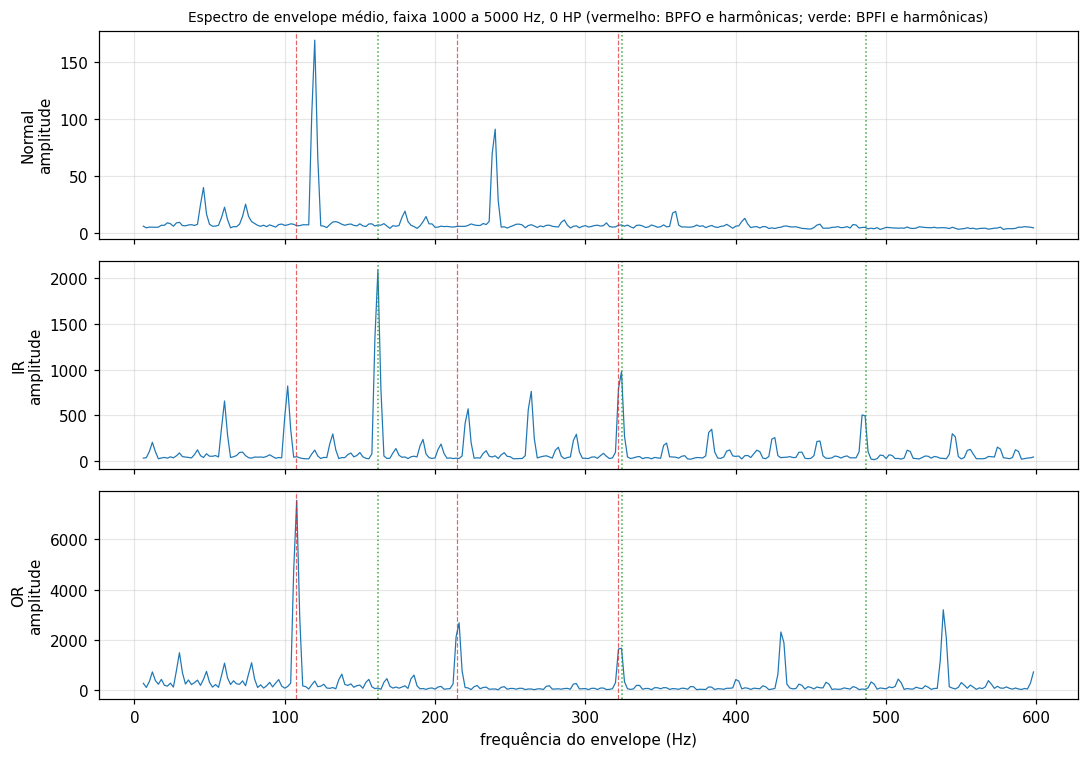

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for ax, cls in zip(axes, CLASSES):
    key = (cls, BASE_SEV[cls], 0)
    g = P1_train[(P1_train.cls == cls) & (P1_train.load == 0)]
    S = env_spectrum(get_windows(key, g.start.values), band_demo).mean(axis=0)
    f = env_freqs(RPM[key] / 60)
    m = (FREQS > 5) & (FREQS < 600)
    ax.plot(FREQS[m], S[m], lw=0.8)
    for k, v in f.items():
        if k.startswith('env_bpfo') and k[-1] in '123':
            ax.axvline(v, color='tab:red', ls='--', lw=0.8, alpha=0.7)
        if k.startswith('env_bpfi') and k[-1] in '123':
            ax.axvline(v, color='tab:green', ls=':', lw=1.0, alpha=0.9)
    ax.set_ylabel(f'{cls}\namplitude')
axes[0].set_title(f'Espectro de envelope médio, faixa {band_demo[0]} a {band_demo[1]} Hz, 0 HP (vermelho: BPFO e harmônicas; verde: BPFI e harmônicas)', fontsize=9)
axes[-1].set_xlabel('frequência do envelope (Hz)')
fig.tight_layout(); fig.savefig(FIG / '04_espectro_envelope.png', bbox_inches='tight'); plt.show()

## 4. Detecção de anomalias (treino só com Normal)

Três detectores não supervisionados, de famílias diferentes: **Isolation Forest** (isolamento por partições aleatórias, Liu et al., 2008),
**One-Class SVM** (fronteira em espaço de kernel, Schölkopf et al., 2001) e **distância de Mahalanobis** com covariância de Ledoit-Wolf (estatístico, adequado quando há poucas amostras para muitos atributos).

**Limiar de decisão.** Sem exemplos de falha no treino, o limiar sai do próprio Normal: percentil 95 dos escores de janelas normais *fora da amostra*, obtidos por validação cruzada em blocos temporais
(cada bloco é segurado de fora e os vizinhos que se sobrepõem a ele são removidos do ajuste). Calibrar com o escore dos próprios dados de treino subestimaria o limiar e inflaria o FPR no teste.
O FPR nominal desse limiar é 5%.

Esse limiar ("temporal") só enxerga variação dentro das condições de treino, porque cada bloco deixado de fora ainda tem a mesma carga que os blocos usados no ajuste. Quando a carga muda, ele pode ficar curto demais.
Por isso reportamos também um segundo limiar, **calibrado por carga**: cada carga de treino é deixada inteira de fora e o percentil 95 sai dos escores dessa carga inédita.
Essa segunda variante foi adicionada depois de ver que a primeira falhava no P2. Nenhuma das duas é ajustada no teste, e as duas aparecem lado a lado em todas as tabelas.

In [9]:
class Detector:
    def __init__(self, kind):
        self.kind = kind
    def fit(self, X):
        self.sc = StandardScaler().fit(X)
        Z = self.sc.transform(X)
        if self.kind == 'iforest':
            self.m = IsolationForest(n_estimators=300, random_state=SEED).fit(Z)
        elif self.kind == 'ocsvm':
            self.m = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05).fit(Z)
        else:
            self.m = LedoitWolf().fit(Z)
        return self
    def score(self, X):
        Z = self.sc.transform(X)
        if self.kind == 'iforest':
            return -self.m.score_samples(Z)
        if self.kind == 'ocsvm':
            return -self.m.decision_function(Z)
        return self.m.mahalanobis(Z)

DET_KINDS = {'iforest': 'Isolation Forest', 'ocsvm': 'One-Class SVM', 'maha': 'Mahalanobis (Ledoit-Wolf)'}

def oof_threshold(kind, X, meta, K=K_FOLDS_THR, q=THR_QUANTILE):
    n = len(X); chunk = np.zeros(n, int)
    for _, g in meta.groupby(['cls', 'sev', 'load']):
        order = g.start.rank(method='first').values - 1
        chunk[g.index.values] = np.floor(order * K / len(g)).astype(int)
    oof = np.full(n, np.nan)
    for k in range(K):
        held = chunk == k
        purge = np.zeros(n, bool)
        for _, g in meta.groupby(['cls', 'sev', 'load']):
            gi, st = g.index.values, g.start.values
            hs = st[held[gi]]
            if len(hs):
                purge[gi[(st > hs.min() - WIN) & (st < hs.max() + WIN)]] = True
        trn = ~held & ~purge
        oof[held] = Detector(kind).fit(X[trn]).score(X[held])
    return float(np.quantile(oof, q)), oof

def threshold_by_load(kind, X, meta, q=THR_QUANTILE):
    # calibração por carga: cada carga de treino é deixada inteira de fora, para o limiar enxergar mudança de condição de operação
    loads = meta['load'].values
    oof = np.full(len(X), np.nan)
    for L in np.unique(loads):
        held = loads == L
        if (~held).sum() >= 10:
            oof[held] = Detector(kind).fit(X[~held]).score(X[held])
    return float(np.quantile(oof[~np.isnan(oof)], q)), oof

## 5. Diagnóstico do tipo de falha

Quatro classificadores supervisionados de famílias diferentes, todos com hiperparâmetros padrão (sem busca em grade, para não otimizar no teste):
**Random Forest**, **SVM com kernel RBF**, **k-vizinhos (k=5)** e **regressão logística**. As entradas são os atributos "tempo + envelope".
Também medimos, só com Random Forest, quanto cada família de atributos contribui (ablação: só tempo, só faixas de frequência, só envelope).

Por fim, o **pipeline em duas etapas** (a ideia sugerida no enunciado): o Isolation Forest decide se a janela é anômala e, só então, um Random Forest treinado apenas com IR e OR decide o tipo.
Testamos duas versões da segunda etapa: com atributos "tempo + envelope" e só com "envelope". A segunda é motivada pela física: atributos de amplitude no tempo carregam o tamanho do defeito,
enquanto o envelope aponta a frequência de falha.

In [10]:
CLASSIFIERS = {
    'Random Forest': lambda: RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    'SVM (RBF)': lambda: make_pipeline(StandardScaler(), SVC(C=10, gamma='scale', random_state=SEED)),
    'kNN (k=5)': lambda: make_pipeline(StandardScaler(), KNeighborsClassifier(5)),
    'Regressão logística': lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
}

def run_fold(tr, te):
    band, band_scores = select_band(tr)
    Ftr, Fte = extract(tr, band), extract(te, band)
    ytr, yte = tr.cls.values, te.cls.values
    out = dict(band=band, Ftr=Ftr, Fte=Fte, ytr=ytr, yte=yte, te=te)
    ntr = ytr == 'Normal'
    Xn = Ftr.loc[ntr, DET_COLS].values
    det = {}
    for kind in DET_KINDS:
        meta_n = tr[ntr].reset_index(drop=True)
        thr, _ = oof_threshold(kind, Xn, meta_n)
        thr_l, _ = threshold_by_load(kind, Xn, meta_n)
        det[kind] = dict(score=Detector(kind).fit(Xn).score(Fte[DET_COLS].values), thr=thr, thr_load=thr_l)
    out['det'] = det
    diag = {}
    for fs_name, cols in FEATURE_SETS.items():
        for m_name, mk in CLASSIFIERS.items():
            if fs_name != MAIN_SET and m_name != 'Random Forest':
                continue
            clf = mk().fit(Ftr[cols].values, ytr)
            diag[(m_name, fs_name)] = clf.predict(Fte[cols].values)
            if m_name == 'Random Forest' and fs_name == MAIN_SET:
                out['rf_main'] = clf
    out['diag'] = diag
    fault = ytr != 'Normal'
    clf_fault = CLASSIFIERS['Random Forest']().fit(Ftr.loc[fault, MAIN_COLS].values, ytr[fault])
    flag = det['iforest']['score'] > det['iforest']['thr']
    out['pipeline'] = np.where(flag, clf_fault.predict(Fte[MAIN_COLS].values), 'Normal')
    clf_fault_env = CLASSIFIERS['Random Forest']().fit(Ftr.loc[fault, ENV_NAMES].values, ytr[fault])
    out['pipeline_env'] = np.where(flag, clf_fault_env.predict(Fte[ENV_NAMES].values), 'Normal')
    flag_l = det['iforest']['score'] > det['iforest']['thr_load']
    out['pipeline_env_load'] = np.where(flag_l, clf_fault_env.predict(Fte[ENV_NAMES].values), 'Normal')
    return out

t0 = time.time()
FOLDS, FOLD_LABELS = {}, {}
FOLDS['P1'], FOLD_LABELS['P1'] = [run_fold(P1_train, P1_test)], ['temporal']
print(f'P1 pronto em {time.time() - t0:.0f} s | faixa: {FOLDS["P1"][0]["band"]}')
FOLDS['P2'], FOLD_LABELS['P2'] = [], [f'{L} HP' for L in LOADS]
for L in LOADS:
    FOLDS['P2'].append(run_fold(*lolo_tables(L)))
    print(f'P2, carga {L} HP fora do treino | faixa: {FOLDS["P2"][-1]["band"]} | acumulado {time.time() - t0:.0f} s')
if USE_EXTRA_SEVERITIES:
    FOLDS['P3'], FOLD_LABELS['P3'] = [], [SEV_LABEL[s] for s in SEVS]
    for s in SEVS:
        FOLDS['P3'].append(run_fold(*sev_tables(s)))
        print(f'P3, defeito de {SEV_LABEL[s]} fora do treino | faixa: {FOLDS["P3"][-1]["band"]} | acumulado {time.time() - t0:.0f} s')

P1 pronto em 22 s | faixa: (1000, 5000)
P2, carga 0 HP fora do treino | faixa: (1000, 5000) | acumulado 38 s
P2, carga 1 HP fora do treino | faixa: (1000, 5000) | acumulado 53 s
P2, carga 2 HP fora do treino | faixa: (1000, 5000) | acumulado 67 s
P2, carga 3 HP fora do treino | faixa: (1000, 5000) | acumulado 80 s
P3, defeito de 0,007" fora do treino | faixa: (5000, 9000) | acumulado 96 s
P3, defeito de 0,014" fora do treino | faixa: (2500, 4500) | acumulado 111 s
P3, defeito de 0,021" fora do treino | faixa: (7000, 8000) | acumulado 126 s


## 6. Resultados

As métricas dos folds de P2 e P3 são **agrupadas** (todas as condições deixadas de fora somadas) para ter mais janelas por classe, e depois abertas por condição.
Os intervalos de confiança de 95% são de Wilson e mostram o tamanho real da incerteza: com poucas dezenas de janelas por classe, uma diferença de poucos pontos percentuais não é significativa.

In [11]:
def wilson(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n; den = 1 + z ** 2 / n
    c = (p + z ** 2 / (2 * n)) / den
    h = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / den
    return c - h, c + h

def fmt(k, n):
    lo, hi = wilson(k, n)
    return f'{100 * k / n:.1f}% [{100 * lo:.1f}; {100 * hi:.1f}] (n={n})'

def det_counts(folds, kind, first_normal_only=False, thr_key='thr'):
    tp = fn = fp = tn = 0; aucs = []
    for i, f in enumerate(folds):
        s, thr, fault = f['det'][kind]['score'], f['det'][kind][thr_key], f['yte'] != 'Normal'
        tp += int((s[fault] > thr).sum()); fn += int((s[fault] <= thr).sum())
        if not (first_normal_only and i > 0):   # no P3 o Normal de teste é o mesmo em todos os folds: conta uma vez
            fp += int((s[~fault] > thr).sum()); tn += int((s[~fault] <= thr).sum())
        aucs.append(roc_auc_score(fault, s))
    return dict(tp=tp, fn=fn, fp=fp, tn=tn, auc=float(np.mean(aucs)))

def cls_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    fault = y_true != 'Normal'
    return dict(cm=cm, recall=dict(zip(CLASSES, cm.diagonal() / cm.sum(1))), acc=float((y_true == y_pred).mean()),
                f1=float(f1_score(y_true, y_pred, average='macro', labels=CLASSES)),
                tpr=(int((y_pred[fault] != 'Normal').sum()), int(fault.sum())),
                fpr=(int((y_pred[~fault] != 'Normal').sum()), int((~fault).sum())))

def pooled(folds, getter):
    return cls_metrics(np.concatenate([f['yte'] for f in folds]), np.concatenate([getter(f) for f in folds]))

PROTO_NAME = {'P1': 'P1 (split temporal 70/30)', 'P2': 'P2 (leave-one-load-out)', 'P3': 'P3 (leave-one-severity-out)'}
CALIB = {'thr': 'limiar temporal', 'thr_load': 'limiar por carga'}

### 6.1 Detecção (treino só com Normal)

A tabela mostra o resultado agrupado, e a seguinte abre por condição deixada de fora. Atenção ao par TPR e AUROC: um AUROC de 1,0 diz que existe um limiar que separa tudo,
mas o TPR e o FPR dependem do limiar que o detector escolheu sozinho, só com dados Normal. É aí que a mudança de condição de operação cobra seu preço.

,Protocolo,Detector,Calibração,TPR,FPR,AUROC
0,P1,Isolation Forest,limiar temporal,100.0% [89.8; 100.0] (n=34),0.0% [0.0; 18.4] (n=17),1.0
1,P1,Isolation Forest,limiar por carga,100.0% [89.8; 100.0] (n=34),0.0% [0.0; 18.4] (n=17),1.0
2,P1,One-Class SVM,limiar temporal,100.0% [89.8; 100.0] (n=34),0.0% [0.0; 18.4] (n=17),1.0
3,P1,One-Class SVM,limiar por carga,100.0% [89.8; 100.0] (n=34),0.0% [0.0; 18.4] (n=17),1.0
4,P1,Mahalanobis (Ledoit-Wolf),limiar temporal,100.0% [89.8; 100.0] (n=34),0.0% [0.0; 18.4] (n=17),1.0
5,P1,Mahalanobis (Ledoit-Wolf),limiar por carga,100.0% [89.8; 100.0] (n=34),0.0% [0.0; 18.4] (n=17),1.0
6,P2,Isolation Forest,limiar temporal,100.0% [97.3; 100.0] (n=140),17.1% [10.1; 27.6] (n=70),1.0
7,P2,Isolation Forest,limiar por carga,100.0% [97.3; 100.0] (n=140),11.4% [5.9; 21.0] (n=70),1.0
8,P2,One-Class SVM,limiar temporal,100.0% [97.3; 100.0] (n=140),77.1% [66.0; 85.4] (n=70),1.0
9,P2,One-Class SVM,limiar por carga,100.0% [97.3; 100.0] (n=140),60.0% [48.3; 70.7] (n=70),1.0


detecção aberta por condição deixada de fora


TPR  \
Detector                 Isolation Forest (limiar temporal)   
Protocolo Fora do treino                                      
P2        0 HP                                          1.0   
          1 HP                                          1.0   
          2 HP                                          1.0   
          3 HP                                          1.0   
P3        0,007"                                        1.0   
          0,014"                                        1.0   
          0,021"                                        1.0   

                                                              \
Detector                 Isolation Forest (limiar por carga)   
Protocolo Fora do treino                                       
P2        0 HP                                           1.0   
          1 HP                                           1.0   
          2 HP                                           1.0   
          3 HP                                           1.0   
P3        0,007"                                         1.0   
          0,014"                                         1.0   
          0,021"                                         1.0   

                                                          \
Detector                 One-Class SVM (limiar temporal)   
Protocolo Fora do treino                                   
P2        0 HP                                       1.0   
          1 HP                                       1.0   
          2 HP                                       1.0   
          3 HP                                       1.0   
P3        0,007"                                     1.0   
          0,014"                                     1.0   
          0,021"                                     1.0   

                                                           \
Detector                 One-Class SVM (limiar por carga)   
Protocolo Fora do treino                                    
P2        0 HP                                        1.0   
          1 HP                                        1.0   
          2 HP                                        1.0   
          3 HP                                        1.0   
P3        0,007"                                      1.0   
          0,014"                                      1.0   
          0,021"                                      1.0   

                                                                      \
Detector                 Mahalanobis (Ledoit-Wolf) (limiar temporal)   
Protocolo Fora do treino                                               
P2        0 HP                                                   1.0   
          1 HP                                                   1.0   
          2 HP                                                   1.0   
          3 HP                                                   1.0   
P3        0,007"                                                 1.0   
          0,014"                                                 1.0   
          0,021"                                                 1.0   

                                                                       \
Detector                 Mahalanobis (Ledoit-Wolf) (limiar por carga)   
Protocolo Fora do treino                                                
P2        0 HP                                                    1.0   
          1 HP                                                    1.0   
          2 HP                                                    1.0   
          3 HP                                                    1.0   
P3        0,007"                                                  1.0   
          0,014"                                                  1.0   
          0,021"                                                  1.0   

                                                        FPR  \
Detector                 Isolation Forest (limiar tempora

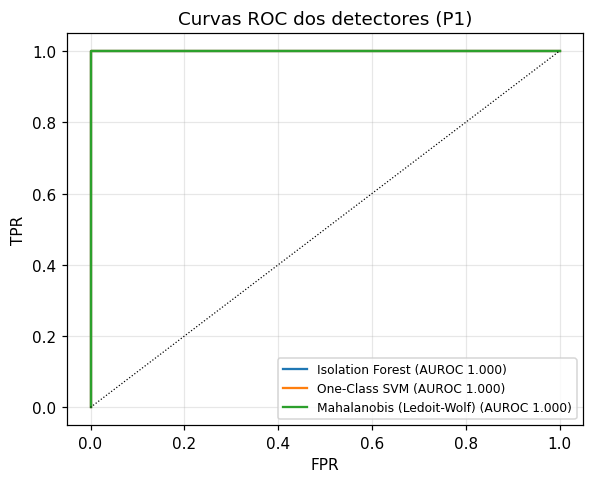

In [12]:
det_rows = []
for proto, folds in FOLDS.items():
    for kind, name in DET_KINDS.items():
        for tk, cal in CALIB.items():
            c = det_counts(folds, kind, first_normal_only=(proto == 'P3'), thr_key=tk)
            det_rows.append({'Protocolo': proto, 'Detector': name, 'Calibração': cal, 'TPR': fmt(c['tp'], c['tp'] + c['fn']), 'FPR': fmt(c['fp'], c['fp'] + c['tn']), 'AUROC': round(c['auc'], 3)})
det_table = pd.DataFrame(det_rows)
display(det_table)

det_fold_rows = []
for proto in ('P2', 'P3'):
    if proto not in FOLDS:
        continue
    for lab, f in zip(FOLD_LABELS[proto], FOLDS[proto]):
        for kind, name in DET_KINDS.items():
            for tk, cal in CALIB.items():
                s, thr, fault = f['det'][kind]['score'], f['det'][kind][tk], f['yte'] != 'Normal'
                det_fold_rows.append({'Protocolo': proto, 'Fora do treino': lab, 'Detector': f'{name} ({cal})',
                                      'TPR': round(float((s[fault] > thr).mean()), 2), 'FPR': round(float((s[~fault] > thr).mean()), 2)})
det_fold_table = pd.DataFrame(det_fold_rows)
print('detecção aberta por condição deixada de fora')
display(det_fold_table.pivot_table(index=['Protocolo', 'Fora do treino'], columns='Detector', values=['TPR', 'FPR'], sort=False))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
f1_ = FOLDS['P1'][0]; fault1 = f1_['yte'] != 'Normal'
for kind, name in DET_KINDS.items():
    fpr, tpr, _ = roc_curve(fault1, f1_['det'][kind]['score'])
    ax.plot(fpr, tpr, label=f'{name} (AUROC {roc_auc_score(fault1, f1_["det"][kind]["score"]):.3f})')
ax.plot([0, 1], [0, 1], 'k:', lw=0.8); ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend(fontsize=8)
ax.set_title('Curvas ROC dos detectores (P1)')
fig.tight_layout(); fig.savefig(FIG / '05_roc_deteccao.png', bbox_inches='tight'); plt.show()

### 6.2 Diagnóstico (3 classes)

In [13]:
diag_rows, DIAG = [], {}
for proto, folds in FOLDS.items():
    for (m_name, fs_name) in folds[0]['diag']:
        m = pooled(folds, lambda f, key=(m_name, fs_name): f['diag'][key])
        DIAG[(proto, m_name, fs_name)] = m
        diag_rows.append({'Protocolo': proto, 'Modelo': m_name, 'Atributos': fs_name, 'Acurácia': round(m['acc'], 3), 'F1 macro': round(m['f1'], 3),
                          'Recall Normal': round(m['recall']['Normal'], 3), 'Recall IR': round(m['recall']['IR'], 3), 'Recall OR': round(m['recall']['OR'], 3)})
    DIAG[(proto, 'Pipeline duas etapas', MAIN_SET)] = pooled(folds, lambda f: f['pipeline'])
    DIAG[(proto, 'Pipeline duas etapas, tipo só por envelope', 'envelope')] = pooled(folds, lambda f: f['pipeline_env'])
    DIAG[(proto, 'Pipeline duas etapas, limiar por carga, tipo só por envelope', 'envelope')] = pooled(folds, lambda f: f['pipeline_env_load'])
diag_table = pd.DataFrame(diag_rows)
print('Modelos com atributos "tempo + envelope"')
display(diag_table[diag_table.Atributos == MAIN_SET].drop(columns='Atributos'))
print('Ablação de atributos (Random Forest)')
display(diag_table[diag_table.Modelo == 'Random Forest'].drop(columns='Modelo'))

Modelos com atributos "tempo + envelope"


,Protocolo,Modelo,Acurácia,F1 macro,Recall Normal,Recall IR,Recall OR
3,P1,Random Forest,1.000,1.000,1.000,1.000,1.000
4,P1,SVM (RBF),1.000,1.000,1.000,1.000,1.000
5,P1,kNN (k=5),1.000,1.000,1.000,1.000,1.000
6,P1,Regressão logística,1.000,1.000,1.000,1.000,1.000
10,P2,Random Forest,1.000,1.000,1.000,1.000,1.000
11,P2,SVM (RBF),1.000,1.000,1.000,1.000,1.000
12,P2,kNN (k=5),1.000,1.000,1.000,1.000,1.000
13,P2,Regressão logística,1.000,1.000,1.000,1.000,1.000
17,P3,Random Forest,0.622,0.597,1.000,0.843,0.324
18,P3,SVM (RBF),0.356,0.360,0.980,0.574,0.000


Ablação de atributos (Random Forest)


,Protocolo,Atributos,Acurácia,F1 macro,Recall Normal,Recall IR,Recall OR
0,P1,tempo,1.000,1.000,1.000,1.000,1.000
1,P1,espectro (faixas),1.000,1.000,1.000,1.000,1.000
2,P1,envelope,1.000,1.000,1.000,1.000,1.000
3,P1,tempo + envelope,1.000,1.000,1.000,1.000,1.000
7,P2,tempo,0.990,0.990,1.000,0.971,1.000
8,P2,espectro (faixas),1.000,1.000,1.000,1.000,1.000
9,P2,envelope,1.000,1.000,1.000,1.000,1.000
10,P2,tempo + envelope,1.000,1.000,1.000,1.000,1.000
14,P3,tempo,0.277,0.328,1.000,0.386,0.000
15,P3,espectro (faixas),0.513,0.544,1.000,0.579,0.333


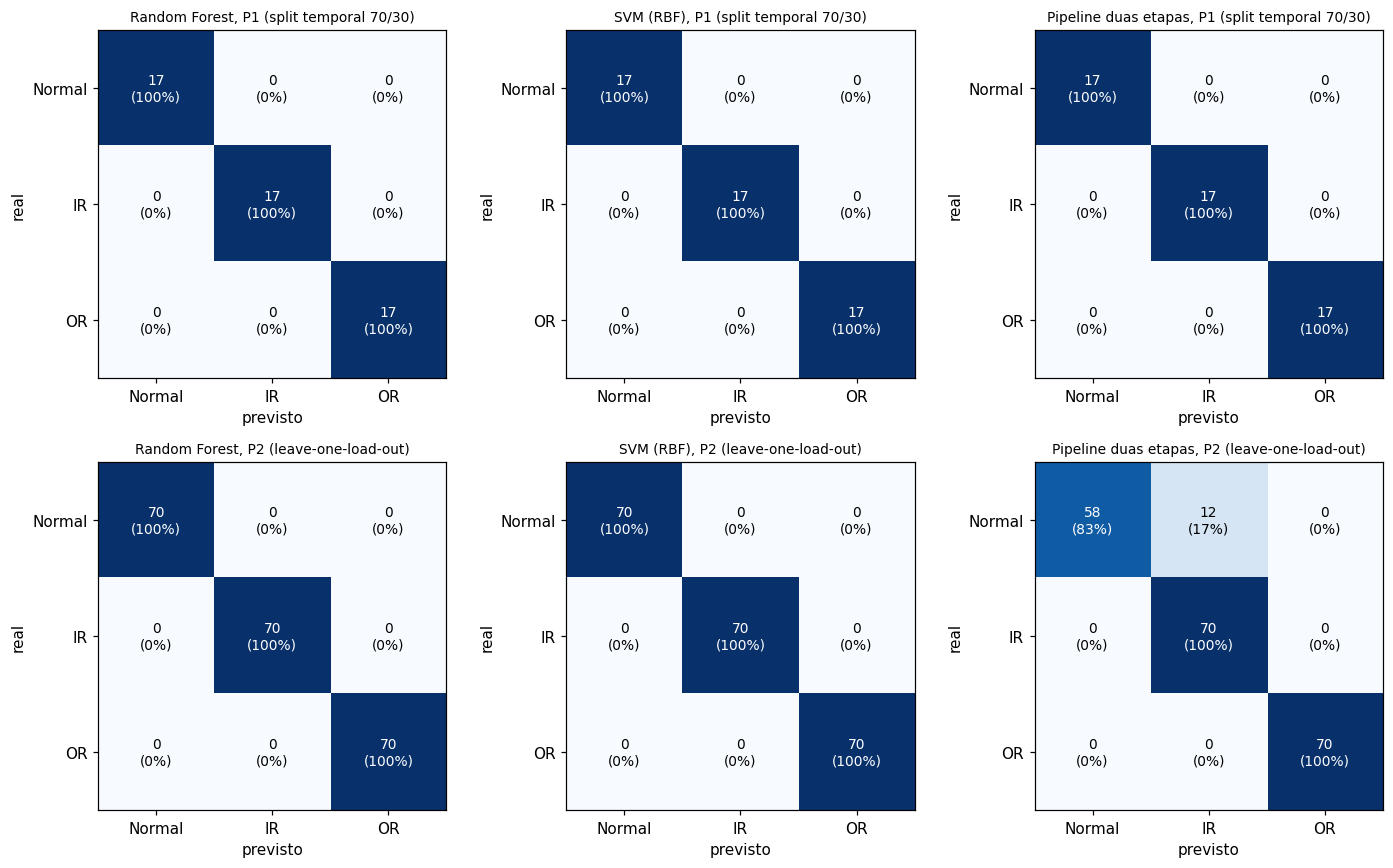

In [14]:
def plot_cm(ax, cm, title):
    ax.imshow(cm / cm.sum(1, keepdims=True), cmap='Blues', vmin=0, vmax=1)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{cm[i, j]}\n({100 * cm[i, j] / cm[i].sum():.0f}%)', ha='center', va='center', fontsize=9,
                    color='white' if cm[i, j] / cm[i].sum() > 0.5 else 'black')
    ax.set_xticks(range(3)); ax.set_yticks(range(3)); ax.set_xticklabels(CLASSES); ax.set_yticklabels(CLASSES)
    ax.set_xlabel('previsto'); ax.set_ylabel('real'); ax.set_title(title, fontsize=9); ax.grid(False)

protos12 = ['P1', 'P2']
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for r, proto in enumerate(protos12):
    for c, m_name in enumerate(['Random Forest', 'SVM (RBF)', 'Pipeline duas etapas']):
        plot_cm(axes[r, c], DIAG[(proto, m_name, MAIN_SET)]['cm'], f'{m_name}, {PROTO_NAME[proto]}')
fig.tight_layout(); fig.savefig(FIG / '06_matrizes_confusao_P1_P2.png', bbox_inches='tight'); plt.show()

### 6.3 O teste mais exigente: tamanho de defeito nunca visto (P3)

Aqui o diagnóstico deixa de ser trivial. Cada coluna abaixo é um fold, com o tamanho de defeito indicado fora do treino. As linhas comparam o Random Forest com atributos de tempo,
de faixas de frequência, de envelope e a combinação tempo + envelope. A hipótese física é que atributos ancorados nas frequências de falha (envelope) generalizam melhor entre tamanhos
do que atributos de amplitude (tempo), que crescem junto com o defeito.

,Defeito fora do treino,Modelo,Atributos,Acurácia,Recall Normal,Recall IR,Recall OR,Faixa usada (Hz)
0,"0,007""",Random Forest,tempo,0.554,1.00,1.00,0.00,5000 a 9000
1,"0,007""",Random Forest,espectro (faixas),0.554,1.00,0.00,1.00,5000 a 9000
2,"0,007""",Random Forest,envelope,0.968,0.71,1.00,1.00,5000 a 9000
3,"0,007""",Random Forest,tempo + envelope,0.987,1.00,1.00,0.97,5000 a 9000
4,"0,007""",SVM (RBF),tempo + envelope,0.554,1.00,1.00,0.00,5000 a 9000
5,"0,007""",kNN (k=5),tempo + envelope,0.975,0.76,1.00,1.00,5000 a 9000
6,"0,007""",Regressão logística,tempo + envelope,0.994,0.94,1.00,1.00,5000 a 9000
7,"0,007""",Pipeline duas etapas,tempo + envelope,0.987,1.00,1.00,0.97,5000 a 9000
8,"0,007""","Pipeline, tipo só por envelope",envelope,1.000,1.00,1.00,1.00,5000 a 9000
9,"0,014""",Random Forest,tempo,0.146,1.00,0.07,0.00,2500 a 4500


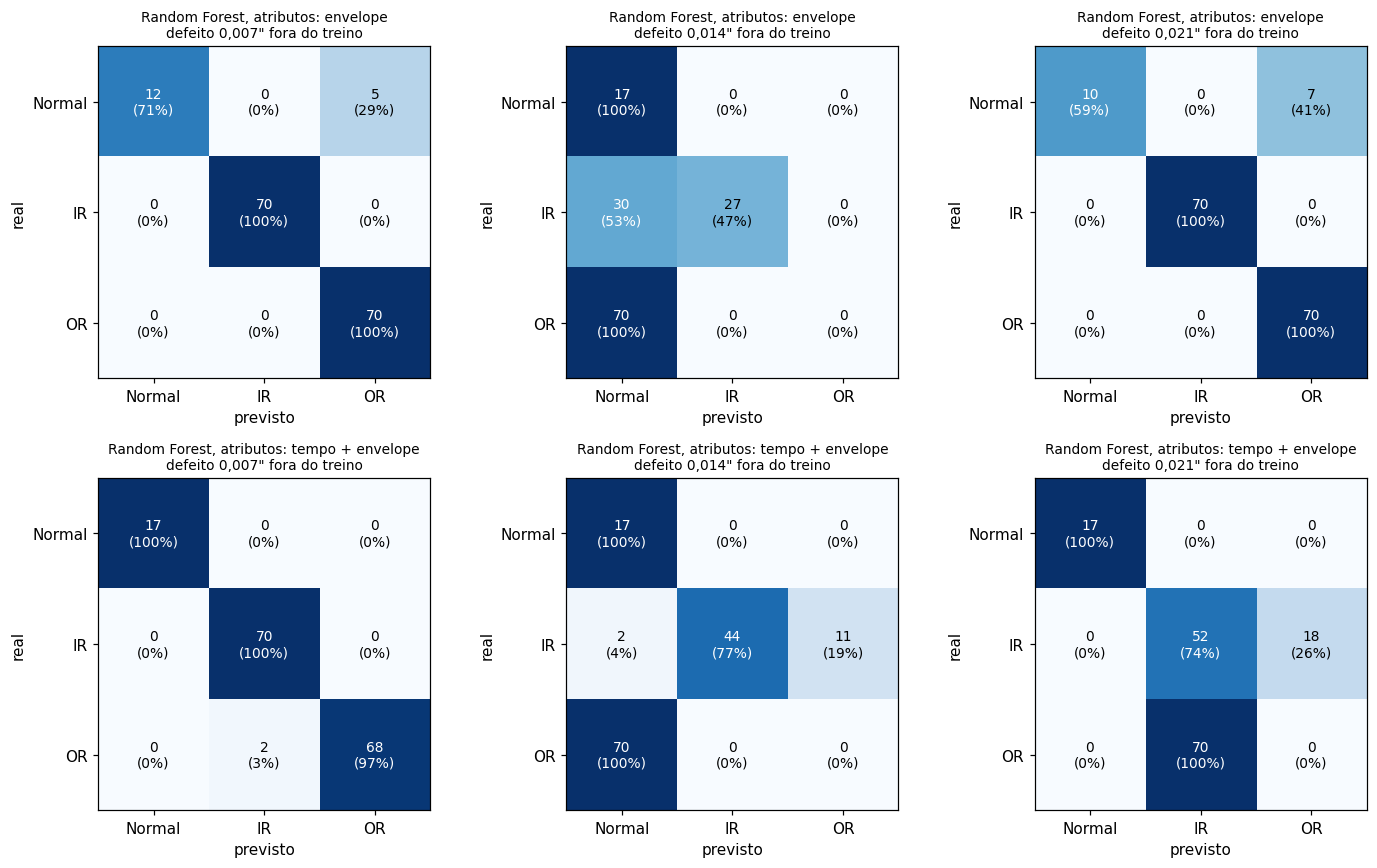

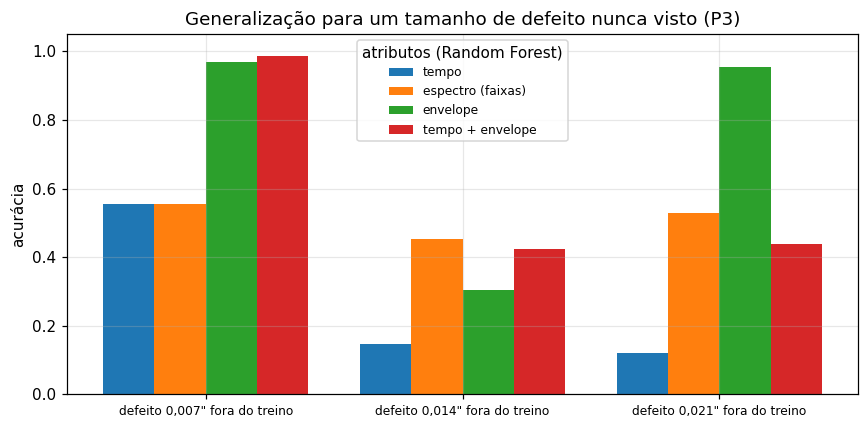

In [15]:
if USE_EXTRA_SEVERITIES:
    p3_rows = []
    for lab, f in zip(FOLD_LABELS['P3'], FOLDS['P3']):
        for (m_name, fs_name), pred in f['diag'].items():
            m = cls_metrics(f['yte'], pred)
            p3_rows.append({'Defeito fora do treino': lab, 'Modelo': m_name, 'Atributos': fs_name, 'Acurácia': round(m['acc'], 3), 'Recall Normal': round(m['recall']['Normal'], 2),
                            'Recall IR': round(m['recall']['IR'], 2), 'Recall OR': round(m['recall']['OR'], 2), 'Faixa usada (Hz)': f'{f["band"][0]} a {f["band"][1]}'})
        m = cls_metrics(f['yte'], f['pipeline'])
        p3_rows.append({'Defeito fora do treino': lab, 'Modelo': 'Pipeline duas etapas', 'Atributos': MAIN_SET, 'Acurácia': round(m['acc'], 3), 'Recall Normal': round(m['recall']['Normal'], 2),
                        'Recall IR': round(m['recall']['IR'], 2), 'Recall OR': round(m['recall']['OR'], 2), 'Faixa usada (Hz)': f'{f["band"][0]} a {f["band"][1]}'})
        m = cls_metrics(f['yte'], f['pipeline_env'])
        p3_rows.append({'Defeito fora do treino': lab, 'Modelo': 'Pipeline, tipo só por envelope', 'Atributos': 'envelope', 'Acurácia': round(m['acc'], 3), 'Recall Normal': round(m['recall']['Normal'], 2),
                        'Recall IR': round(m['recall']['IR'], 2), 'Recall OR': round(m['recall']['OR'], 2), 'Faixa usada (Hz)': f'{f["band"][0]} a {f["band"][1]}'})
    p3_table = pd.DataFrame(p3_rows)
    display(p3_table)

    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    for c, (lab, f) in enumerate(zip(FOLD_LABELS['P3'], FOLDS['P3'])):
        for r, fs_name in enumerate(['envelope', 'tempo + envelope']):
            plot_cm(axes[r, c], cls_metrics(f['yte'], f['diag'][('Random Forest', fs_name)])['cm'], f'Random Forest, atributos: {fs_name}\ndefeito {lab} fora do treino')
    fig.tight_layout(); fig.savefig(FIG / '09_matrizes_confusao_P3.png', bbox_inches='tight'); plt.show()

    fig, ax = plt.subplots(figsize=(8, 4))
    w = 0.2
    for i, fs_name in enumerate(FEATURE_SETS):
        vals = [cls_metrics(f['yte'], f['diag'][('Random Forest', fs_name)])['acc'] for f in FOLDS['P3']]
        ax.bar(np.arange(3) + (i - 1.5) * w, vals, w, label=fs_name)
    ax.set_xticks(range(3)); ax.set_xticklabels([f'defeito {l} fora do treino' for l in FOLD_LABELS['P3']], fontsize=8)
    ax.set_ylabel('acurácia'); ax.set_ylim(0, 1.05); ax.legend(fontsize=8, title='atributos (Random Forest)')
    ax.set_title('Generalização para um tamanho de defeito nunca visto (P3)')
    fig.tight_layout(); fig.savefig(FIG / '10_P3_atributos.png', bbox_inches='tight'); plt.show()

### 6.4 Por que o defeito de 0,014" é o mais difícil?

Antes de culpar o modelo, olhamos o dado. A tabela mostra o SNR médio (log10) do pico esperado no espectro de envelope, em BPFI para IR e em BPFO para OR (média das 3 primeiras harmônicas e das 4 cargas),
para quatro faixas de demodulação (as quatro que os folds de P1 e P3 escolheram). Quanto maior o valor, mais visível é a assinatura do defeito.
Se o 0,014" aparece mais fraco que os outros tamanhos em todas as faixas, o problema não é a escolha da faixa, e sim que o tamanho do defeito não ordena a força da assinatura.

In [16]:
def mean_snr(key, band, names):
    x = SIG[key]
    starts = np.arange(0, len(x) - WIN + 1, WIN)
    W = get_windows(key, starts)
    S = env_spectrum(W, band); f = env_freqs(RPM[key] / 60)
    return float(np.mean([local_snr(S, f[k]) for k in names], axis=0).mean())

if USE_EXTRA_SEVERITIES:
    bands_show = [(1000, 5000), (2500, 4500), (5000, 9000), (7000, 8000)]
    nm = {'IR': ['env_bpfi1', 'env_bpfi2', 'env_bpfi3'], 'OR': ['env_bpfo1', 'env_bpfo2', 'env_bpfo3']}
    snr_rows = []
    for cls in ('IR', 'OR'):
        for sev in SEVS:
            r = {'classe': cls, 'defeito': SEV_LABEL[sev]}
            for b in bands_show:
                r[f'{b[0]} a {b[1]} Hz'] = round(np.mean([mean_snr((cls, sev, L), b, nm[cls]) for L in LOADS]), 2)
            snr_rows.append(r)
    snr_table = pd.DataFrame(snr_rows)
    display(snr_table)
    snr_table.to_csv(RES / 'snr_envelope_por_severidade.csv', index=False, encoding='utf-8')

,classe,defeito,1000 a 5000 Hz,2500 a 4500 Hz,5000 a 9000 Hz,7000 a 8000 Hz
0,IR,"0,007""",1.40,1.35,1.14,1.27
1,IR,"0,014""",0.48,0.47,0.61,0.62
2,IR,"0,021""",0.76,0.95,0.97,0.85
3,OR,"0,007""",1.45,1.45,1.35,1.46
4,OR,"0,014""",0.30,0.30,0.21,0.25
5,OR,"0,021""",0.94,0.92,0.79,0.70


## 7. Por que P1 e P2 não diferenciam os métodos

Duas verificações explicam o teto de 100%. Primeiro, repetimos o diagnóstico com o procedimento que muitos trabalhos usam: janelas com sobreposição de todos os sinais, sorteadas ao acaso em 70% treino e 30% teste
(janelas vizinhas caem nos dois lados). Segundo, medimos quanto um **único atributo** já resolve, com uma árvore de profundidade 2.
Se um atributo isolado como o RMS resolve o problema, o problema padrão do CWRU com defeito de 0,007" não mede qualidade de método.

,Protocolo,"Acurácia (Random Forest, tempo + envelope)",F1 macro
0,Ingênuo (split aleatório de janelas),1.000,1.000
1,P1 (split temporal 70/30),1.000,1.000
2,P2 (leave-one-load-out),1.000,1.000
3,P3 (leave-one-severity-out),0.622,0.597


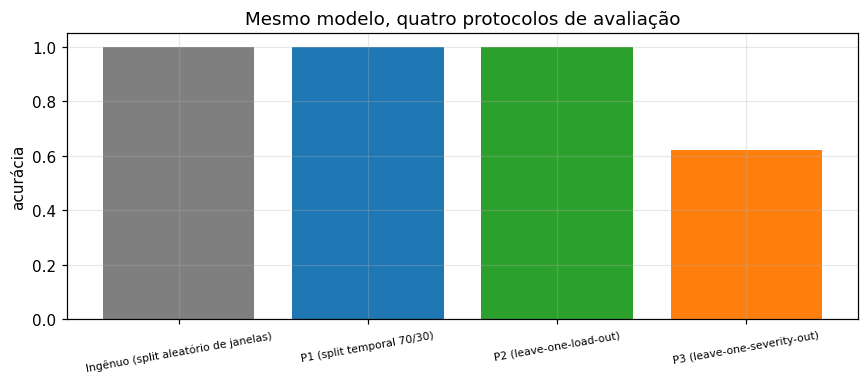

árvore de profundidade 2 usando UM atributo, protocolo P2 (carga nunca vista)


,atributo único,acurácia no P2
0,rms,1.000
9,banda_1-2kHz,1.000
5,fator_forma,1.000
17,env_bpfo1,1.000
11,banda_3-4kHz,1.000
1,pico,0.986
8,banda_0.5-1kHz,0.981
10,banda_2-3kHz,0.952


In [17]:
def run_naive():
    tbl = build_table(BASE_KEYS, 0.0, 1.0, HOP_FIT)
    tr_i, te_i = train_test_split(np.arange(len(tbl)), test_size=0.3, stratify=tbl.cls.values, random_state=SEED)
    tr, te = tbl.iloc[tr_i].reset_index(drop=True), tbl.iloc[te_i].reset_index(drop=True)
    band, _ = select_band(tr)
    Ftr, Fte = extract(tr, band), extract(te, band)
    clf = CLASSIFIERS['Random Forest']().fit(Ftr[MAIN_COLS].values, tr.cls.values)
    return cls_metrics(te.cls.values, clf.predict(Fte[MAIN_COLS].values))

naive = run_naive()
cmp_rows = [('Ingênuo (split aleatório de janelas)', naive['acc'], naive['f1'])]
for proto in FOLDS:
    m = DIAG[(proto, 'Random Forest', MAIN_SET)]
    cmp_rows.append((PROTO_NAME[proto], m['acc'], m['f1']))
cmp_df = pd.DataFrame(cmp_rows, columns=['Protocolo', 'Acurácia (Random Forest, tempo + envelope)', 'F1 macro']).round(3)
display(cmp_df)

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(range(len(cmp_df)), cmp_df.iloc[:, 1], color=['tab:gray', 'tab:blue', 'tab:green', 'tab:orange'][:len(cmp_df)])
ax.set_xticks(range(len(cmp_df))); ax.set_xticklabels(cmp_df['Protocolo'], fontsize=7, rotation=10)
ax.set_ylim(0, 1.05); ax.set_ylabel('acurácia'); ax.set_title('Mesmo modelo, quatro protocolos de avaliação')
fig.tight_layout(); fig.savefig(FIG / '07_protocolos.png', bbox_inches='tight'); plt.show()

stump = []
for col in TIME_NAMES + BAND_NAMES + ENV_NAMES:
    yt, yp = [], []
    for f in FOLDS['P2']:
        m = DecisionTreeClassifier(max_depth=2, random_state=SEED).fit(f['Ftr'][[col]].values, f['ytr'])
        yp += list(m.predict(f['Fte'][[col]].values)); yt += list(f['yte'])
    stump.append((col, float(np.mean(np.array(yt) == np.array(yp)))))
stump_df = pd.DataFrame(stump, columns=['atributo único', 'acurácia no P2']).sort_values('acurácia no P2', ascending=False).head(8).round(3)
print('árvore de profundidade 2 usando UM atributo, protocolo P2 (carga nunca vista)')
display(stump_df)

## 8. O que o modelo está usando?

Importância por permutação do Random Forest (queda no F1 macro quando se embaralha um atributo), calculada em cada carga deixada de fora e promediada.
Como o P2 está saturado, a importância tende a ser baixa e espalhada, porque embaralhar um atributo isolado não derruba um modelo que tem vários atributos redundantes. O P3 é onde o diagnóstico depende de fato de atributos específicos.

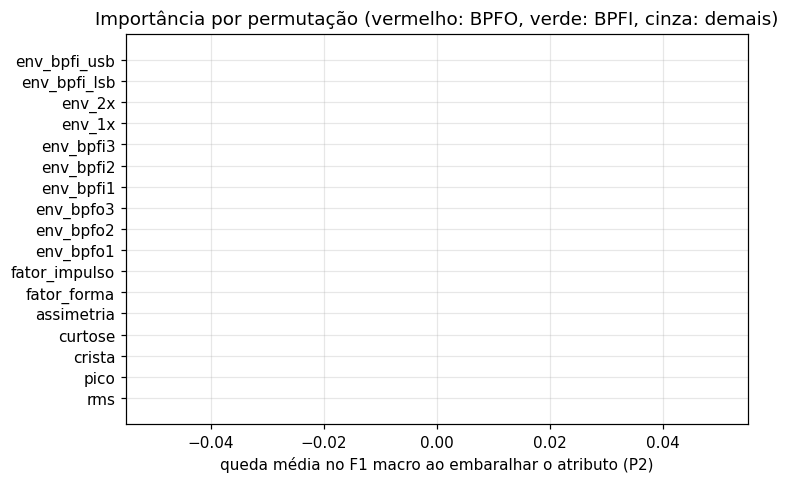

In [18]:
imp = []
for f in FOLDS['P2']:
    r = permutation_importance(f['rf_main'], f['Fte'][MAIN_COLS].values, f['yte'], n_repeats=10, scoring='f1_macro', random_state=SEED, n_jobs=1)
    imp.append(r.importances_mean)
imp = pd.Series(np.mean(imp, axis=0), index=MAIN_COLS).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(imp.index, imp.values, color=['tab:red' if 'bpfo' in n else 'tab:green' if 'bpfi' in n else 'tab:gray' for n in imp.index])
ax.set_xlabel('queda média no F1 macro ao embaralhar o atributo (P2)')
ax.set_title('Importância por permutação (vermelho: BPFO, verde: BPFI, cinza: demais)')
fig.tight_layout(); fig.savefig(FIG / '08_importancia.png', bbox_inches='tight'); plt.show()

## 9. Tabela resumo (formato do enunciado)

Acrescentamos a coluna "Protocolo", porque a mesma técnica tem resultados bem diferentes em P1, P2 e P3 e isso faz parte da análise.
"Tipo de falha identificada" lista as classes do dataset que o modelo de fato reconheceu (recall maior que zero). Detectores não classificam, então ficam como "não se aplica".
No P3 as janelas Normal de teste são as mesmas nos três folds. Nos detectores elas são contadas uma vez, e nos classificadores cada fold tem seu próprio modelo, então as janelas Normal aparecem uma vez por fold.

In [19]:
rows = []
for proto, folds in FOLDS.items():
    for kind, name in DET_KINDS.items():
        for tk, cal in CALIB.items():
            c = det_counts(folds, kind, first_normal_only=(proto == 'P3'), thr_key=tk)
            rows.append({'Dataset': 'CWRU', 'Técnica': f'{name} ({cal}; tempo + faixas de frequência, treino só Normal)', 'Protocolo': PROTO_NAME[proto],
                         'Tipo de falha identificada': 'não se aplica', 'TPR (IC 95%)': fmt(c['tp'], c['tp'] + c['fn']),
                         'FPR (IC 95%)': fmt(c['fp'], c['fp'] + c['tn']), 'Acurácia por classe': f'não se aplica (AUROC {c["auc"]:.3f})'})
    for m_name in list(CLASSIFIERS) + ['Pipeline duas etapas']:
        m = DIAG[(proto, m_name, MAIN_SET)]
        rec = m['recall']
        ident = ', '.join(c for c in ('IR', 'OR') if rec[c] > 0) or 'nenhuma'
        rows.append({'Dataset': 'CWRU', 'Técnica': m_name + (' (tempo + envelope)' if m_name != 'Pipeline duas etapas' else ' (Isolation Forest + Random Forest)'),
                     'Protocolo': PROTO_NAME[proto], 'Tipo de falha identificada': ident,
                     'TPR (IC 95%)': fmt(*m['tpr']), 'FPR (IC 95%)': fmt(*m['fpr']),
                     'Acurácia por classe': ' | '.join(f'{c} {100 * rec[c]:.1f}%' for c in CLASSES)})
    m = DIAG[(proto, 'Pipeline duas etapas, tipo só por envelope', 'envelope')]
    rec = m['recall']
    rows.append({'Dataset': 'CWRU', 'Técnica': 'Pipeline duas etapas (Isolation Forest + Random Forest só com envelope)', 'Protocolo': PROTO_NAME[proto],
                 'Tipo de falha identificada': ', '.join(c for c in ('IR', 'OR') if rec[c] > 0) or 'nenhuma',
                 'TPR (IC 95%)': fmt(*m['tpr']), 'FPR (IC 95%)': fmt(*m['fpr']),
                 'Acurácia por classe': ' | '.join(f'{c} {100 * rec[c]:.1f}%' for c in CLASSES)})
    m = DIAG[(proto, 'Pipeline duas etapas, limiar por carga, tipo só por envelope', 'envelope')]
    rec = m['recall']
    rows.append({'Dataset': 'CWRU', 'Técnica': 'Pipeline duas etapas (Isolation Forest com limiar por carga + Random Forest só com envelope)', 'Protocolo': PROTO_NAME[proto],
                 'Tipo de falha identificada': ', '.join(c for c in ('IR', 'OR') if rec[c] > 0) or 'nenhuma',
                 'TPR (IC 95%)': fmt(*m['tpr']), 'FPR (IC 95%)': fmt(*m['fpr']),
                 'Acurácia por classe': ' | '.join(f'{c} {100 * rec[c]:.1f}%' for c in CLASSES)})
    if proto == 'P3':
        m = DIAG[(proto, 'Random Forest', 'envelope')]
        rec = m['recall']
        rows.append({'Dataset': 'CWRU', 'Técnica': 'Random Forest (somente envelope)', 'Protocolo': PROTO_NAME[proto],
                     'Tipo de falha identificada': ', '.join(c for c in ('IR', 'OR') if rec[c] > 0) or 'nenhuma',
                     'TPR (IC 95%)': fmt(*m['tpr']), 'FPR (IC 95%)': fmt(*m['fpr']),
                     'Acurácia por classe': ' | '.join(f'{c} {100 * rec[c]:.1f}%' for c in CLASSES)})
tabela = pd.DataFrame(rows)
display(tabela)

tabela.to_csv(RES / 'tabela_resumo.csv', index=False, encoding='utf-8')
md = '| ' + ' | '.join(tabela.columns) + ' |\n|' + '---|' * len(tabela.columns) + '\n'
md += '\n'.join('| ' + ' | '.join(str(v) for v in r) + ' |' for r in tabela.values)
(RES / 'tabela_resumo.md').write_text(md + '\n', encoding='utf-8')
det_fold_table.to_csv(RES / 'deteccao_por_condicao.csv', index=False, encoding='utf-8')
if USE_EXTRA_SEVERITIES:
    p3_table.to_csv(RES / 'diagnostico_P3_por_severidade.csv', index=False, encoding='utf-8')

metricas = {'config': dict(FS=FS, WIN=WIN, HOP_FIT=HOP_FIT, HOP_EVAL=HOP_EVAL, GUARD=GUARD, TRAIN_FRAC=TRAIN_FRAC, THR_QUANTILE=THR_QUANTILE, SEED=SEED),
            'faixa_demodulacao_Hz': {p: [f['band'] for f in fs] for p, fs in FOLDS.items()},
            'matrizes_confusao': {f'{p}|{m}|{s}': v['cm'].tolist() for (p, m, s), v in DIAG.items()},
            'protocolo_ingenuo': {'acc': naive['acc'], 'f1': naive['f1']}}
(RES / 'metricas.json').write_text(json.dumps(metricas, indent=2, ensure_ascii=False), encoding='utf-8')
print('arquivos salvos em', RES)

,Dataset,Técnica,Protocolo,Tipo de falha identificada,TPR (IC 95%),FPR (IC 95%),Acurácia por classe
0,CWRU,Isolation Forest (limiar temporal; tempo + fai...,P1 (split temporal 70/30),não se aplica,100.0% [89.8; 100.0] (n=34),0.0% [0.0; 18.4] (n=17),não se aplica (AUROC 1.000)
1,CWRU,Isolation Forest (limiar por carga; tempo + fa...,P1 (split temporal 70/30),não se aplica,100.0% [89.8; 100.0] (n=34),0.0% [0.0; 18.4] (n=17),não se aplica (AUROC 1.000)
2,CWRU,One-Class SVM (limiar temporal; tempo + faixas...,P1 (split temporal 70/30),não se aplica,100.0% [89.8; 100.0] (n=34),0.0% [0.0; 18.4] (n=17),não se aplica (AUROC 1.000)
3,CWRU,One-Class SVM (limiar por carga; tempo + faixa...,P1 (split temporal 70/30),não se aplica,100.0% [89.8; 100.0] (n=34),0.0% [0.0; 18.4] (n=17),não se aplica (AUROC 1.000)
4,CWRU,Mahalanobis (Ledoit-Wolf) (limiar temporal; te...,P1 (split temporal 70/30),não se aplica,100.0% [89.8; 100.0] (n=34),0.0% [0.0; 18.4] (n=17),não se aplica (AUROC 1.000)
5,CWRU,Mahalanobis (Ledoit-Wolf) (limiar por carga; t...,P1 (split temporal 70/30),não se aplica,100.0% [89.8; 100.0] (n=34),0.0% [0.0; 18.4] (n=17),não se aplica (AUROC 1.000)
6,CWRU,Random Forest (tempo + envelope),P1 (split temporal 70/30),"IR, OR",100.0% [89.8; 100.0] (n=34),0.0% [0.0; 18.4] (n=17),Normal 100.0% | IR 100.0% | OR 100.0%
7,CWRU,SVM (RBF) (tempo + envelope),P1 (split temporal 70/30),"IR, OR",100.0% [89.8; 100.0] (n=34),0.0% [0.0; 18.4] (n=17),Normal 100.0% | IR 100.0% | OR 100.0%
8,CWRU,kNN (k=5) (tempo + envelope),P1 (split temporal 70/30),"IR, OR",100.0% [89.8; 100.0] (n=34),0.0% [0.0; 18.4] (n=17),Normal 100.0% | IR 100.0% | OR 100.0%
9,CWRU,Regressão logística (tempo + envelope),P1 (split temporal 70/30),"IR, OR",100.0% [89.8; 100.0] (n=34),0.0% [0.0; 18.4] (n=17),Normal 100.0% | IR 100.0% | OR 100.0%


arquivos salvos em c:\Users\Mauro\Documents\GitHub\IMT_CD_PROJETO_2\results


## 10. Apêndice: correções que tentamos e o que aconteceu

Duas hipóteses para consertar os pontos fracos dos resultados, testadas **sem escolher a variante pelo desempenho no teste**: as duas variantes são reportadas lado a lado.

**A. A falha do P3 em 0,014" é culpa da faixa de demodulação?** Comparamos quatro faixas fixas e uma seleção "maximin" (a faixa cujo pior caso entre os tamanhos de defeito do treino é o melhor). Mede-se a acurácia do Random Forest só com envelope.

**B. O FPR alto do P2 vem de atributos que carregam a amplitude, que muda com a carga?** Repetimos a detecção com atributos invariantes à escala (fator de crista, curtose, assimetria, fator de forma, fator de impulso e a fração de energia por faixa).

O apêndice leva cerca de 3 minutos. Para pular, use `RUN_APPENDIX = False`.

In [20]:
RUN_APPENDIX = True
if RUN_APPENDIX and USE_EXTRA_SEVERITIES:
    def select_band_maximin(tr, n_per_class=40):
        groups = []
        for cls in ('IR', 'OR'):
            g = tr[tr.cls == cls]
            g = g.sample(min(n_per_class, len(g)), random_state=SEED)
            for key, gg in g.groupby(['cls', 'sev', 'load']):
                groups.append((cls, key[1], get_windows(key, gg.start.values), RPM[key] / 60))
        keys = {'IR': ['env_bpfi1', 'env_bpfi2', 'env_bpfi3'], 'OR': ['env_bpfo1', 'env_bpfo2', 'env_bpfo3']}
        out = []
        for band in CAND_BANDS:
            per = {}
            for cls, sev, W, fr in groups:
                S = env_spectrum(W, band); f = env_freqs(fr)
                per.setdefault((cls, sev), []).append(np.mean([local_snr(S, f[k]) for k in keys[cls]], axis=0))
            sevs = sorted({s for (_, s) in per})
            out.append((band, min(np.mean([np.concatenate(per[(c, s)]).mean() for c in ('IR', 'OR')]) for s in sevs)))
        return max(out, key=lambda t: t[1])[0]

    def rf_env_eval(tr, te, band):
        Ftr, Fte = extract(tr, band), extract(te, band)
        p = CLASSIFIERS['Random Forest']().fit(Ftr[ENV_NAMES].values, tr.cls.values).predict(Fte[ENV_NAMES].values)
        yt = te.cls.values
        return {'Acurácia': round(float((p == yt).mean()), 3), 'Recall IR': round(float((p[yt == 'IR'] == 'IR').mean()), 2), 'Recall OR': round(float((p[yt == 'OR'] == 'OR').mean()), 2)}

    ap_rows = []
    for s in SEVS:
        tr, te = sev_tables(s)
        for b in [(1000, 5000), (2500, 4500), (5000, 9000), (3000, 7000)]:
            ap_rows.append({'Defeito fora do treino': SEV_LABEL[s], 'Faixa (Hz)': f'{b[0]} a {b[1]} (fixa)', **rf_env_eval(tr, te, b)})
        bm = select_band_maximin(tr)
        ap_rows.append({'Defeito fora do treino': SEV_LABEL[s], 'Faixa (Hz)': f'{bm[0]} a {bm[1]} (maximin)', **rf_env_eval(tr, te, bm)})
    apA = pd.DataFrame(ap_rows)
    print('A. Random Forest só com envelope, P3, por faixa de demodulação')
    display(apA)
    apA.to_csv(RES / 'apendice_A_faixas_P3.csv', index=False, encoding='utf-8')

    INV_COLS_T = ['crista', 'curtose', 'assimetria', 'fator_forma', 'fator_impulso']
    def add_rel(F):
        F = F.copy()
        tot = np.log10(sum(10 ** F[c] for c in BAND_NAMES))
        for c in BAND_NAMES:
            F['rel_' + c] = F[c] - tot
        return F
    INV_COLS = INV_COLS_T + ['rel_' + c for c in BAND_NAMES]
    apB_rows = []
    for tag, cols in (('absolutos (usados no trabalho)', DET_COLS), ('invariantes à escala', INV_COLS)):
        for L in LOADS:
            tr, te = lolo_tables(L)
            Ftr, Fte = add_rel(extract(tr)), add_rel(extract(te))
            ntr = tr.cls.values == 'Normal'; Xn = Ftr.loc[ntr, cols].values
            fault = te.cls.values != 'Normal'
            for kind, name in DET_KINDS.items():
                thr, _ = oof_threshold(kind, Xn, tr[ntr].reset_index(drop=True))
                s_ = Detector(kind).fit(Xn).score(Fte[cols].values)
                apB_rows.append({'Atributos': tag, 'Carga fora do treino': f'{L} HP', 'Detector': name, 'TPR': round(float((s_[fault] > thr).mean()), 2), 'FPR': round(float((s_[~fault] > thr).mean()), 2)})
    apB = pd.DataFrame(apB_rows)
    print('B. detecção no P2, atributos absolutos contra invariantes à escala')
    display(apB.pivot_table(index=['Atributos', 'Carga fora do treino'], columns='Detector', values='FPR', sort=False))
    apB.to_csv(RES / 'apendice_B_deteccao_P2.csv', index=False, encoding='utf-8')

A. Random Forest só com envelope, P3, por faixa de demodulação


,Defeito fora do treino,Faixa (Hz),Acurácia,Recall IR,Recall OR
0,"0,007""",1000 a 5000 (fixa),0.936,0.86,1.00
1,"0,007""",2500 a 4500 (fixa),0.987,1.00,1.00
2,"0,007""",5000 a 9000 (fixa),0.968,1.00,1.00
3,"0,007""",3000 a 7000 (fixa),0.987,1.00,1.00
4,"0,007""",10500 a 14500 (maximin),0.981,0.97,1.00
5,"0,014""",1000 a 5000 (fixa),0.431,0.79,0.00
6,"0,014""",2500 a 4500 (fixa),0.306,0.47,0.00
7,"0,014""",5000 a 9000 (fixa),0.479,0.91,0.00
8,"0,014""",3000 a 7000 (fixa),0.306,0.47,0.00
9,"0,014""",4000 a 8000 (maximin),0.215,0.25,0.00


B. detecção no P2, atributos absolutos contra invariantes à escala


Detector                                             Isolation Forest  \
Atributos                      Carga fora do treino                     
absolutos (usados no trabalho) 0 HP                              1.00   
                               1 HP                              0.00   
                               2 HP                              0.05   
                               3 HP                              0.05   
invariantes à escala           0 HP                              1.00   
                               1 HP                              0.00   
                               2 HP                              0.00   
                               3 HP                              0.00   

Detector                                             One-Class SVM  \
Atributos                      Carga fora do treino                  
absolutos (usados no trabalho) 0 HP                            1.0   
                               1 HP                            1.0   
                               2 HP                            0.2   
                               3 HP                            1.0   
invariantes à escala           0 HP                            1.0   
                               1 HP                            1.0   
                               2 HP                            0.1   
                               3 HP                            1.0   

Detector                                             Mahalanobis (Ledoit-Wolf)  
Atributos                      Carga fora do treino                             
absolutos (usados no trabalho) 0 HP                                       1.00  
                               1 HP                                       1.00  
                               2 HP                                       0.40  
                               3 HP                                       1.00  
invariantes à escala           0 HP                                       1.00  
                               1 HP                                       1.00  
                               2 HP                                       0.05  
                               3 HP                                       0.70

## 11. Conclusões

Os números exatos estão nas tabelas acima e no relatório. As mensagens qualitativas que o experimento sustenta são estas.

**O cenário padrão do CWRU não diferencia métodos.** Com defeito de 0,007", P1 e P2 saturam, e um único atributo (o RMS) já separa as três classes. Para esse recorte, qualquer modelo razoável "funciona", e a nota máxima da acurácia não prova robustez.

**A diferença aparece quando a condição muda.** Na detecção, o AUROC continua perfeito, mas o limiar aprendido só com Normal deixa de valer quando a carga muda: com a calibração temporal, o Isolation Forest sofre menos que o One-Class SVM e o Mahalanobis.
Calibrar o limiar deixando uma carga inteira de fora reduz muito o FPR do Mahalanobis. O que sobra de erro vem da carga de 0 HP, que fica fora da faixa das outras três cargas (extrapolação), e nenhum limiar resolve isso.
No diagnóstico, trocar o tamanho do defeito derruba os atributos de amplitude no tempo e expõe a fragilidade da seleção da faixa de demodulação.

**Separar os papéis ajuda.** O melhor resultado em P3 vem do pipeline em que estatísticas gerais só detectam e o envelope, ancorado nas frequências físicas de falha, só diz o tipo.

**Nem o envelope resolve tudo.** No defeito de 0,014" a assinatura em BPFO e BPFI é bem mais fraca que nos outros tamanhos, em todas as faixas testadas, e o modelo erra de forma sistemática. As duas correções que tentamos (apêndice) não resolveram.

## 12. Limitações a discutir no relatório

Os pontos abaixo vêm da própria estrutura do experimento e devem ser confrontados com os números das seções anteriores, não aceitos de saída.

**Tamanho amostral.** São 4 sinais por condição, de 5 a 10 segundos cada. O número de janelas de teste por classe é pequeno, e por isso todas as taxas vêm com intervalo de confiança.

**Um único rolamento e uma única máquina.** Todas as janelas de uma classe vêm da mesma bancada, do mesmo rolamento defeituoso por classe e tamanho. P2 e P3 testam mudança de carga e de tamanho de defeito,
mas não de rolamento, de máquina nem de ponto de medição. Smith e Randall (2015) discutem esse limite do CWRU e outras armadilhas do dataset.

**Escolhas feitas no treino.** A faixa de demodulação usa rótulos de falha do treino e varia entre folds. Para a etapa de detecção isso foi evitado de propósito (os atributos de detecção não dependem dela).
Uma seleção de faixa mais estável (por exemplo, curtose espectral) é o próximo passo natural.

**Limiar do detector.** O limiar é calibrado só com Normal das condições vistas. Quando a carga muda, o Normal muda junto, e o limiar deixa de valer mesmo que o detector ainda ordene bem as janelas (AUROC alto com FPR alto).

**Sem ajuste de hiperparâmetros.** Foi uma escolha para não otimizar no teste. Uma busca com validação cruzada em blocos temporais é o próximo passo natural.

**Dados reais com falha artificial.** Os defeitos do CWRU foram feitos por eletroerosão, não por fadiga. A assinatura é mais limpa do que a de uma falha que evolui sozinha.

**Higiene dos arquivos.** Vários arquivos do CWRU têm variáveis trocadas ou duplicadas (seção 1.1), e o pacote do Kaggle indicado no enunciado traz um Normal de 2 HP duplicado. Sem a conferência explícita, essas falhas passam sem aviso.

In [21]:
print(f'Python {sys.version.split()[0]} | numpy {np.__version__} | scikit-learn {__import__("sklearn").__version__} | pandas {pd.__version__}')
print(f'tempo total de execução: {time.time() - T0:.0f} s')

Python 3.13.14 | numpy 2.4.2 | scikit-learn 1.8.0 | pandas 3.0.1
tempo total de execução: 255 s
